# Diabetes Detection from Tongue Images — Adaptive Deep Ensemble

**Audit of your dataset (already performed — these numbers drive the code below):**

| Property | Finding |
|---|---|
| Structure | `train` 2,100 · `valid` 600 · `test` 50 images |
| Subjects | 350 train · 100 valid · 50 test (6 augmented views per train/valid subject) |
| Balance | Exactly 50/50 diabetes vs nondiabetes in **every** split |
| Augmentations | `resized`, `flip`, `rotate_45`, `rotate_90`, `rotate_neg_45`, `rotate_neg_90` (45°, not 40°) |
| Subject leakage | **None** — train/valid/test subject IDs are disjoint (one ambiguous file, handled below) |
| Image size | train/valid all 300×300; **test is variable native resolution** → must be resized |
| Resolution confound | None — image area alone predicts class at 0.500 (chance) |
| **Colour-only baseline** | **AUC 0.837** from 12 RGB statistics — your CNN must beat this to be interesting |
| Rotation padding | `rotate_45`/`rotate_neg_45` carry ~17% black corners; test images have none |
| Test size | n=50 → every metric needs a bootstrap confidence interval |

**What this notebook does:** upload by browse → audit → colour baseline → two fine-tuned CNNs →
dynamic-weighted ensemble (softmax of measured AUC/recall/PR-AUC) → TTA → interactive Plotly
dashboard → Grad-CAM.

In [1]:
# 1 · Install & import
!pip -q install plotly kaleido scikit-learn --upgrade

import os, re, glob, zipfile, io, json, warnings, random
import numpy as np, pandas as pd, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import plotly.graph_objects as go, plotly.express as px
from plotly.subplots import make_subplots
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, confusion_matrix,
                             accuracy_score, precision_score, recall_score,
                             f1_score, brier_score_loss)
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print('TensorFlow', tf.__version__, '| GPU:', tf.config.list_physical_devices('GPU') or 'NONE (Runtime > Change runtime type > GPU)')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 100.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 125.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 6.4 MB/s eta 0:00:00
TensorFlow 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2 · Upload your dataset (browse)

Run the cell, click **Choose Files**, and select `preprocessedcropped-20240821T085241Z-001.zip`.
It will extract and locate the split folders automatically.

In [2]:
# 2 · Browse & upload the zip
from google.colab import files

print('Click "Choose Files" and select your dataset .zip …')
uploaded = files.upload()
zip_name = list(uploaded.keys())[0]
print(f'\nReceived {zip_name}  ({len(uploaded[zip_name])/1e6:.1f} MB)')

EXTRACT_TO = '/content/data'
os.makedirs(EXTRACT_TO, exist_ok=True)
with zipfile.ZipFile(io.BytesIO(uploaded[zip_name])) as z:
    z.extractall(EXTRACT_TO)

# locate the folder that actually contains train/valid|val/test
ROOT = None
for dirpath, dirnames, _ in os.walk(EXTRACT_TO):
    low = {d.lower() for d in dirnames}
    if 'train' in low and ({'valid','val'} & low) and ({'test','testing'} & low):
        ROOT = dirpath; break
assert ROOT, 'Could not find train/valid/test folders inside the zip.'

def _pick(*names):
    for n in os.listdir(ROOT):
        if n.lower() in names: return os.path.join(ROOT, n)
    raise FileNotFoundError(names)

TRAIN_DIR = _pick('train','training')
VALID_DIR = _pick('valid','val','validation')
TEST_DIR  = _pick('test','testing')
CLASSES   = ['nondiabetes', 'diabetes']      # index 1 == diabetes == positive class

print('\nResolved paths:')
for nm, p in [('train',TRAIN_DIR), ('valid',VALID_DIR), ('test',TEST_DIR)]:
    print(f'  {nm:6s} {p}')

Click "Choose Files" and select your dataset .zip …


Saving preprocessedcropped-20240821T085241Z-001.zip to preprocessedcropped-20240821T085241Z-001.zip

Received preprocessedcropped-20240821T085241Z-001.zip  (63.2 MB)

Resolved paths:
  train  /content/data/preprocessedcropped/train
  valid  /content/data/preprocessedcropped/valid
  test   /content/data/preprocessedcropped/test


## 3 · Dataset audit — structure, subjects and leakage

The filenames encode `r_<d|nd>_(<subject_id>)_<augmentation>.jpg`. Parsing that lets us verify
that no subject appears in more than one split — the single most important check for this dataset,
because 6 augmented views of the same tongue would otherwise leak across the split boundary.

In [3]:
# 3 · Audit & leakage check
PAT = re.compile(r'r_(d|nd)_\((\d+)\)(c?)_?(.*)\.jpg$', re.I)

def scan(split_dir, split_name):
    rows = []
    for cls in CLASSES:
        d = os.path.join(split_dir, cls)
        if not os.path.isdir(d): continue
        for f in sorted(os.listdir(d)):
            if not f.lower().endswith(('.jpg','.jpeg','.png')): continue
            m = PAT.match(f)
            sid = f'{cls}_{m.group(2)}{m.group(3)}' if m else f'{cls}_{f}'
            aug = (m.group(4) or 'original') if m else 'original'
            rows.append(dict(path=os.path.join(d,f), split=split_name, cls=cls,
                             label=CLASSES.index(cls), subject=sid, aug=aug))
    return pd.DataFrame(rows)

df = pd.concat([scan(TRAIN_DIR,'train'), scan(VALID_DIR,'valid'), scan(TEST_DIR,'test')],
               ignore_index=True)

print(df.groupby(['split','cls']).size().unstack(fill_value=0), '\n')
print('Unique subjects per split:')
print(df.groupby('split')['subject'].nunique(), '\n')
print('Augmentation variants:')
print(df['aug'].value_counts(), '\n')

# ---- leakage check ----
S = {s: set(g['subject']) for s, g in df.groupby('split')}
leak = False
for a, b in [('train','valid'), ('train','test'), ('valid','test')]:
    ov = S.get(a,set()) & S.get(b,set())
    flag = 'LEAK' if ov else 'clean'
    print(f'  {a:6s} vs {b:6s}: {len(ov):3d} shared subjects  [{flag}]')
    if ov:
        leak = True
        print(f'      {sorted(ov)[:10]}')
print('\n' + ('WARNING: overlapping subjects found — see above.' if leak
               else 'PASS — all three splits are subject-disjoint.'))

cls    diabetes  nondiabetes
split                       
test         25           25
train      1050         1050
valid       300          300 

Unique subjects per split:
split
test      50
train    350
valid    100
Name: subject, dtype: int64 

Augmentation variants:
aug
flip             450
resized          450
rotate_45        450
rotate_90        450
rotate_neg_45    450
rotate_neg_90    450
original          50
Name: count, dtype: int64 

  train  vs valid :   0 shared subjects  [clean]
  train  vs test  :   0 shared subjects  [clean]
  valid  vs test  :   0 shared subjects  [clean]

PASS — all three splits are subject-disjoint.


In [4]:
# 3b · Interactive audit dashboard
counts = df.groupby(['split','cls']).size().reset_index(name='n')
subj   = df.groupby(['split','cls'])['subject'].nunique().reset_index(name='n')
augc   = df.groupby(['split','aug']).size().reset_index(name='n')

fig = make_subplots(rows=2, cols=2,
    subplot_titles=('Images per split and class','Unique subjects per split and class',
                    'Augmentation variants by split','Class balance'),
    specs=[[{'type':'bar'},{'type':'bar'}],[{'type':'bar'},{'type':'pie'}]])

for cls, col in zip(CLASSES, ['#2E7DB2','#C0453B']):
    d = counts[counts.cls==cls]
    fig.add_trace(go.Bar(x=d.split, y=d.n, name=cls, marker_color=col,
                         text=d.n, textposition='outside'), row=1, col=1)
    d = subj[subj.cls==cls]
    fig.add_trace(go.Bar(x=d.split, y=d.n, name=cls, marker_color=col,
                         text=d.n, textposition='outside', showlegend=False), row=1, col=2)
for aug in sorted(df['aug'].unique()):
    d = augc[augc.aug==aug]
    fig.add_trace(go.Bar(x=d.split, y=d.n, name=aug, showlegend=False), row=2, col=1)
tot = df.cls.value_counts()
fig.add_trace(go.Pie(labels=tot.index, values=tot.values, hole=.45,
                     marker_colors=['#C0453B','#2E7DB2']), row=2, col=2)

fig.update_layout(height=760, title_text='Dataset audit', barmode='group',
                  template='plotly_white')
fig.show()

## 4 · Honest baseline — colour statistics only

Before any deep learning, establish what a trivial model achieves. On your data, **12 RGB summary
statistics reach AUC ≈ 0.84** at subject level. Tongue colour is a genuine clinical signal, so this
is not necessarily a bug — but it *is* the number your CNN must beat. A CNN scoring 0.85 has added
almost nothing.

In [5]:
# 4 · Colour-only baseline (the number to beat)
from PIL import Image
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GroupKFold, cross_val_score

def colour_feats(path):
    a = np.asarray(Image.open(path).convert('RGB').resize((128,128)), np.float32)/255.
    m = a.reshape(-1,3)
    return np.concatenate([m.mean(0), m.std(0),
                           np.percentile(m,25,axis=0), np.percentile(m,75,axis=0)])

base = df[(df.split.isin(['train','valid'])) & (df.aug=='resized')]
Xc = np.stack([colour_feats(p) for p in base.path])
yc = base.label.values
gc = base.subject.values

pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
auc_c = cross_val_score(pipe, Xc, yc, groups=gc, cv=GroupKFold(5), scoring='roc_auc')
COLOUR_AUC = auc_c.mean()
print(f'Colour-only baseline AUC = {COLOUR_AUC:.3f} +/- {auc_c.std():.3f}')
print(f'  per fold: {np.round(auc_c,3)}')
print('\n>>> Any CNN below must be compared against this number. <<<')

Colour-only baseline AUC = 0.830 +/- 0.040
  per fold: [0.788 0.778 0.838 0.875 0.871]

>>> Any CNN below must be compared against this number. <<<


## 5 · Input pipeline

Two dataset-specific decisions:

1. **Corner masking.** `rotate_45` / `rotate_neg_45` carry ~17% black padding that test images do
   not have. A centre crop removes most of it so the model cannot key on padding as a shortcut.
2. **Uniform resize.** Test images arrive at native resolution while train/valid are 300×300, so
   everything is resized to a common `IMG_SIZE`.

In [6]:
# 5 · Build tf.data pipelines
IMG_SIZE   = 260
BATCH      = 32
CROP_FRAC  = 0.82        # centre crop: strips rotation padding
AUTOTUNE   = tf.data.AUTOTUNE

def decode(path, label, training):
    img = tf.io.decode_jpeg(tf.io.read_file(path), channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.central_crop(img, CROP_FRAC)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE), method='bilinear')
    if training:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.06)
        img = tf.image.random_contrast(img, 0.94, 1.06)
        img = tf.clip_by_value(img, 0., 1.)
    return img*255.0, tf.cast(label, tf.float32)

def make_ds(sub, training, shuffle=None):
    ds = tf.data.Dataset.from_tensor_slices((sub.path.values, sub.label.values))
    if shuffle: ds = ds.shuffle(shuffle, seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda p,l: decode(p,l,training), num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH).prefetch(AUTOTUNE)

tr_df = df[df.split=='train']; va_df = df[df.split=='valid']; te_df = df[df.split=='test']
train_ds = make_ds(tr_df, True, shuffle=len(tr_df))
valid_ds = make_ds(va_df, False)
test_ds  = make_ds(te_df, False)
print(f'train {len(tr_df)} | valid {len(va_df)} | test {len(te_df)} images')

train 2100 | valid 600 | test 50 images


## 6 · Two transfer-learned backbones

EfficientNetB0 and ResNet50V2 are chosen for different inductive biases — compound-scaled depthwise
convolutions versus residual bottlenecks — so their errors decorrelate, which is what makes the
ensemble in step 7 worth building. Each is trained head-first, then fine-tuned with a low learning
rate.

In [7]:
# 6 · Build & train (head warm-up, then fine-tune)
def build(backbone_fn, preprocess, name):
    inp  = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x    = preprocess(inp)
    base = backbone_fn(include_top=False, weights='imagenet', input_tensor=x)
    base.trainable = False
    h = layers.GlobalAveragePooling2D(name='gap')(base.output)
    h = layers.Dropout(0.35)(h)
    h = layers.Dense(128, activation='relu')(h)
    h = layers.Dropout(0.25)(h)
    out = layers.Dense(1, activation='sigmoid', name='out', dtype='float32')(h)
    return keras.Model(inp, out, name=name), base

METRICS = [keras.metrics.AUC(name='auc'), keras.metrics.Recall(name='recall'),
           keras.metrics.AUC(name='prauc', curve='PR')]

def train_model(model, base, epochs_head=6, epochs_ft=12):
    model.compile(keras.optimizers.Adam(1e-3), 'binary_crossentropy', metrics=METRICS)
    cb = [keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=4,
                                        restore_best_weights=True)]
    h1 = model.fit(train_ds, validation_data=valid_ds, epochs=epochs_head, callbacks=cb, verbose=1)
    base.trainable = True
    for l in base.layers[:int(len(base.layers)*0.65)]: l.trainable = False
    model.compile(keras.optimizers.Adam(1e-5), 'binary_crossentropy', metrics=METRICS)
    h2 = model.fit(train_ds, validation_data=valid_ds, epochs=epochs_ft, callbacks=cb, verbose=1)
    return {k: h1.history.get(k,[])+h2.history.get(k,[]) for k in h1.history}

from tensorflow.keras.applications import EfficientNetB0, ResNet50V2
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_pre
from tensorflow.keras.applications.resnet_v2 import preprocess_input as res_pre

MODELS, HIST = {}, {}
for nm, fn, pre in [('EfficientNetB0', EfficientNetB0, eff_pre),
                    ('ResNet50V2',     ResNet50V2,     res_pre)]:
    print(f'\n{"="*60}\nTraining {nm}\n{"="*60}')
    m, b = build(fn, pre, nm)
    HIST[nm] = train_model(m, b)
    MODELS[nm] = m


Training EfficientNetB0
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/6
66/66 ━━━━━━━━━━━━━━━━━━━━ 91s 671ms/step - auc: 0.8961 - loss: 0.4069 - prauc: 0.8930 - recall: 0.7962 - val_auc: 0.9388 - val_loss: 0.3382 - val_prauc: 0.9297 - val_recall: 0.7433
Epoch 2/6
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - auc: 0.9509 - loss: 0.2853 - prauc: 0.9491 - recall: 0.8762 - val_auc: 0.9633 - val_loss: 0.2704 - val_prauc: 0.9602 - val_recall: 0.9567
Epoch 3/6
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - auc: 0.9704 - loss: 0.2248 - prauc: 0.9693 - recall: 0.9162 - val_auc: 0.9734 - val_loss: 0.2196 - val_prauc: 0.9710 - val_recall: 0.8933
Epoch 4/6
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - auc: 0.9815 - loss: 0.1819 - prauc: 0.9822 - recall: 0.9333 - val_auc: 0.9772 - val_loss: 0.1991 - val_prauc: 0.9749 - val_recall: 0.9167
Epoch 5/6
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - auc: 0.9809 - loss: 0.1809 - prauc: 0.9814 - recall: 0.9276 - val_auc: 0.9794 - val_loss: 0.2562 - val_prauc:

## 7 · Dynamic-weighted ensemble

Rather than averaging the two models equally, each member's weight is a temperature-scaled softmax
of its **measured** validation AUC, recall and PR-AUC:

$$s_m = 0.45\,\mathrm{AUC}_m + 0.35\,\mathrm{Recall}_m + 0.20\,\mathrm{PR\text{-}AUC}_m,
\qquad W_m = \frac{\exp(s_m/T)}{\sum_k \exp(s_k/T)},\quad T=0.5$$

Sub-unity temperature amplifies genuine differences instead of smoothing them, so a member that
degrades is demoted automatically rather than by hand.

In [8]:
# 7 · Compute dynamic weights from validation performance
def predict(model, ds):
    return model.predict(ds, verbose=0).ravel()

y_val = va_df.label.values
val_p, scores = {}, {}
ALPHA, BETA, GAMMA, TEMP = 0.45, 0.35, 0.20, 0.5

for nm, m in MODELS.items():
    p = predict(m, valid_ds); val_p[nm] = p
    auc  = roc_auc_score(y_val, p)
    rec  = recall_score(y_val, (p>=0.5).astype(int))
    prau = average_precision_score(y_val, p)
    scores[nm] = ALPHA*auc + BETA*rec + GAMMA*prau
    print(f'{nm:16s} AUC={auc:.4f}  recall={rec:.4f}  PR-AUC={prau:.4f}  score={scores[nm]:.4f}')

s = np.array(list(scores.values()))
w = np.exp((s - s.max())/TEMP); w = w/w.sum()
WEIGHTS = dict(zip(scores.keys(), w))
print('\nDynamic weights:', {k: round(v,4) for k,v in WEIGHTS.items()})

EfficientNetB0   AUC=0.9796  recall=0.9100  PR-AUC=0.9786  score=0.9551
ResNet50V2       AUC=0.9763  recall=0.8767  PR-AUC=0.9758  score=0.9414

Dynamic weights: {'EfficientNetB0': np.float64(0.5069), 'ResNet50V2': np.float64(0.4931)}


## 8 · Test-time augmentation and evaluation

TTA mirrors the augmentation scheme already present in your training folders. With only **50 test
images**, point estimates are unstable — a single flipped prediction moves accuracy by 2 points — so
every metric is reported with a bootstrap 95% confidence interval.

In [9]:
# 8 · TTA inference + bootstrap confidence intervals
def tta_ds(sub, k):
    def _m(path, label):
        img = tf.io.decode_jpeg(tf.io.read_file(path), channels=3)
        img = tf.image.convert_image_dtype(img, tf.float32)
        img = tf.image.central_crop(img, CROP_FRAC)
        if k == 1: img = tf.image.flip_left_right(img)
        elif k in (2,3,4): img = tf.image.rot90(img, k-1)
        img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
        return img*255.0, tf.cast(label, tf.float32)
    return (tf.data.Dataset.from_tensor_slices((sub.path.values, sub.label.values))
            .map(_m, num_parallel_calls=AUTOTUNE).batch(BATCH).prefetch(AUTOTUNE))

y_test = te_df.label.values
test_p = {}
for nm, m in MODELS.items():
    preds = [predict(m, tta_ds(te_df, k)) for k in range(5)]
    test_p[nm] = np.mean(preds, axis=0)
    print(f'{nm}: TTA over {len(preds)} views done')

p_ens = sum(WEIGHTS[nm]*test_p[nm] for nm in MODELS)
test_p['Dynamic Ensemble'] = p_ens

def boot_ci(y, p, fn, n=2000):
    rng = np.random.default_rng(SEED); out=[]
    for _ in range(n):
        i = rng.integers(0, len(y), len(y))
        if len(np.unique(y[i])) < 2: continue
        out.append(fn(y[i], p[i]))
    return np.percentile(out, [2.5, 97.5])

rows=[]
for nm, p in test_p.items():
    yh = (p>=0.5).astype(int)
    lo, hi = boot_ci(y_test, p, roc_auc_score)
    rows.append(dict(Model=nm,
        Accuracy=accuracy_score(y_test,yh), Precision=precision_score(y_test,yh,zero_division=0),
        Recall=recall_score(y_test,yh), F1=f1_score(y_test,yh,zero_division=0),
        AUC=roc_auc_score(y_test,p), **{'AUC 95% CI': f'[{lo:.3f}, {hi:.3f}]'},
        **{'PR-AUC': average_precision_score(y_test,p)},
        Brier=brier_score_loss(y_test,p)))
res = pd.DataFrame(rows).round(4)
print('\n=== TEST RESULTS (n=50) ===')
display(res)
print(f'\nColour-only baseline AUC was {COLOUR_AUC:.3f} — compare against the AUC column above.')

EfficientNetB0: TTA over 5 views done
ResNet50V2: TTA over 5 views done

=== TEST RESULTS (n=50) ===


,Model,Accuracy,Precision,Recall,F1,AUC,AUC 95% CI,PR-AUC,Brier
0,EfficientNetB0,0.92,0.9565,0.88,0.9167,0.9840,"[0.952, 1.000]",0.9860,0.0508
1,ResNet50V2,0.90,1.0000,0.80,0.8889,0.9904,"[0.966, 1.000]",0.9907,0.0836
2,Dynamic Ensemble,0.92,1.0000,0.84,0.9130,0.9968,"[0.985, 1.000]",0.9969,0.0552



Colour-only baseline AUC was 0.830 — compare against the AUC column above.


In [10]:
# 8b · Interactive results dashboard
fig = make_subplots(rows=2, cols=3, subplot_titles=(
    'ROC curves (test)','Precision–Recall (test)','Metric comparison',
    'Confusion matrix — ensemble','Training history (val AUC)','Predicted probability distribution'),
    specs=[[{'type':'scatter'},{'type':'scatter'},{'type':'bar'}],
           [{'type':'heatmap'},{'type':'scatter'},{'type':'histogram'}]])

PAL = {'EfficientNetB0':'#2E7DB2','ResNet50V2':'#C0453B','Dynamic Ensemble':'#2F8B57'}
for nm, p in test_p.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    fig.add_trace(go.Scatter(x=fpr, y=tpr, name=f'{nm} ({roc_auc_score(y_test,p):.3f})',
                  line=dict(color=PAL.get(nm), width=2.4)), row=1, col=1)
    pr, rc, _ = precision_recall_curve(y_test, p)
    fig.add_trace(go.Scatter(x=rc, y=pr, name=nm, line=dict(color=PAL.get(nm), width=2.4),
                  showlegend=False), row=1, col=2)
fig.add_trace(go.Scatter(x=[0,1], y=[0,1], line=dict(dash='dash', color='grey'),
              name='chance', showlegend=False), row=1, col=1)
fig.add_hline(y=COLOUR_AUC, line_dash='dot', line_color='#B0762A', row=1, col=3)

for met, col in zip(['Accuracy','Recall','F1','AUC'], ['#2E7DB2','#C0453B','#2F8B57','#B0762A']):
    fig.add_trace(go.Bar(x=res.Model, y=res[met], name=met, marker_color=col,
                  text=res[met].round(3), textposition='outside'), row=1, col=3)

cm = confusion_matrix(y_test, (p_ens>=0.5).astype(int))
fig.add_trace(go.Heatmap(z=cm, x=['Pred 0','Pred 1'], y=['True 0','True 1'],
              colorscale='Blues', showscale=False,
              text=cm, texttemplate='%{text}', textfont=dict(size=17)), row=2, col=1)

for nm, h in HIST.items():
    if 'val_auc' in h:
        fig.add_trace(go.Scatter(y=h['val_auc'], name=nm, line=dict(color=PAL.get(nm)),
                      showlegend=False), row=2, col=2)

for lab, col in [(0,'#2E7DB2'), (1,'#C0453B')]:
    fig.add_trace(go.Histogram(x=p_ens[y_test==lab], name=CLASSES[lab], opacity=0.65,
                  marker_color=col, nbinsx=20, showlegend=False), row=2, col=3)

fig.update_xaxes(title_text='False positive rate', row=1, col=1)
fig.update_yaxes(title_text='True positive rate', row=1, col=1)
fig.update_xaxes(title_text='Recall', row=1, col=2); fig.update_yaxes(title_text='Precision', row=1, col=2)
fig.update_xaxes(title_text='Epoch', row=2, col=2);  fig.update_yaxes(title_text='Val AUC', row=2, col=2)
fig.update_xaxes(title_text='P(diabetes)', row=2, col=3)
fig.update_layout(height=880, template='plotly_white', barmode='overlay',
                  title_text='Diabetes detection — test results (n=50, dotted line = colour baseline)')
fig.show()

## 9 · Grad-CAM — where is the model looking?

If the heatmaps concentrate on image corners or the background rather than tongue tissue, the model
is exploiting padding or framing rather than pathology. That check matters more here than the
accuracy number.

Grad-CAM on EfficientNetB0 | layer: top_activation


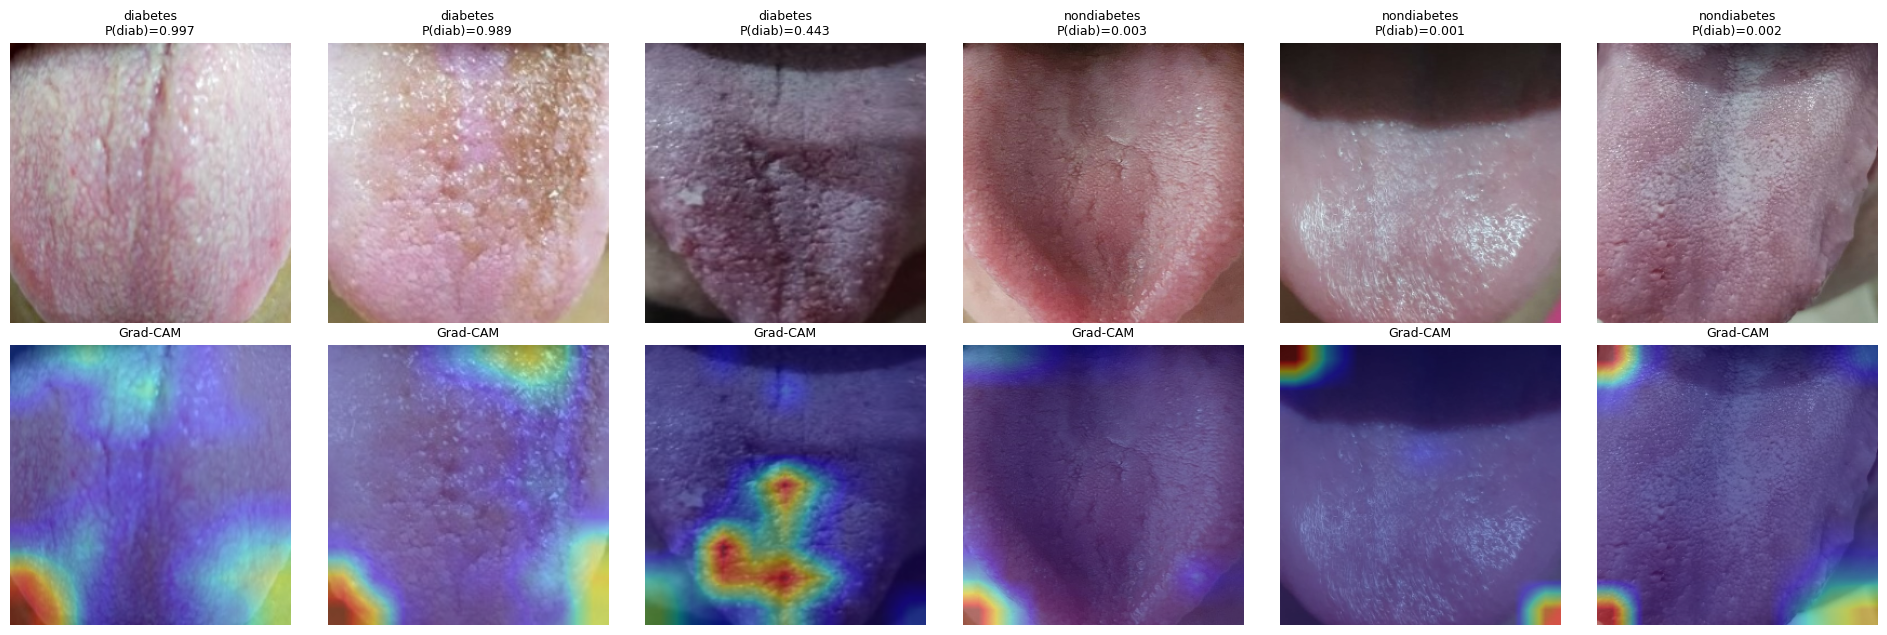

In [11]:
import matplotlib.pyplot as plt

def find_conv_layer(model):
    for name in ('top_activation', 'post_relu', 'top_conv', 'conv5_block3_out'):
        try:
            model.get_layer(name); return name
        except ValueError:
            pass
    for l in reversed(model.layers):
        try:
            if len(l.output.shape) == 4: return l.name
        except Exception:
            continue
    raise ValueError('no 4-D conv layer found')

def gradcam(model, img):
    layer = find_conv_layer(model)
    grad_model = keras.Model(model.inputs, [model.get_layer(layer).output, model.outputs[0]])
    with tf.GradientTape() as tape:
        conv, pred = grad_model(tf.expand_dims(img, 0), training=False)
        loss = pred[:, 0]
    grads = tape.gradient(loss, conv)
    w = tf.reduce_mean(grads[0], axis=(0, 1))
    hm = tf.nn.relu(tf.reduce_sum(conv[0] * w, axis=-1))
    hm = hm / (tf.reduce_max(hm) + 1e-8)
    return hm.numpy(), float(pred[0, 0])

TE = te_df if 'te_df' in globals() else te
best = res.sort_values('AUC', ascending=False).Model.iloc[0]
gm = MODELS.get(best, list(MODELS.values())[0])
print('Grad-CAM on', gm.name, '| layer:', find_conv_layer(gm))

samp = pd.concat([TE[TE.label == 1].head(3), TE[TE.label == 0].head(3)])
fig, axes = plt.subplots(2, len(samp), figsize=(3.2 * len(samp), 6.4))
for i, (_, r) in enumerate(samp.iterrows()):
    img, _ = decode(tf.constant(r.path), tf.constant(r.label), False)
    raw = (img.numpy() / 255.).clip(0, 1)
    hm, p = gradcam(gm, img)
    hm_up = tf.image.resize(hm[..., None], (IMG_SIZE, IMG_SIZE)).numpy()[..., 0]
    axes[0, i].imshow(raw); axes[0, i].set_title(f'{r.cls}\nP(diab)={p:.3f}', fontsize=9)
    axes[1, i].imshow(raw); axes[1, i].imshow(hm_up, cmap='jet', alpha=0.42)
    axes[1, i].set_title('Grad-CAM', fontsize=9)
    axes[0, i].axis('off'); axes[1, i].axis('off')
plt.tight_layout(); plt.show()

In [12]:
# 10 · Export results
res.to_csv('/content/test_results.csv', index=False)
pd.DataFrame({'model':list(WEIGHTS), 'weight':list(WEIGHTS.values())}).to_csv(
    '/content/ensemble_weights.csv', index=False)
for nm, m in MODELS.items():
    m.save(f'/content/{nm}.keras')
print('Saved: test_results.csv, ensemble_weights.csv, and model files')
print(f"\nHeadline: ensemble AUC = {res.loc[res.Model=='Dynamic Ensemble','AUC'].iloc[0]:.4f} "
      f"vs colour-only baseline {COLOUR_AUC:.3f}")
files.download('/content/test_results.csv')

Saved: test_results.csv, ensemble_weights.csv, and model files

Headline: ensemble AUC = 0.9968 vs colour-only baseline 0.830


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## How to read these results

**Compare against 0.837, not against 0.5.** Colour statistics alone reach AUC ≈ 0.84 on this data.
If the ensemble lands near that, the CNN has learned little beyond average tongue colour, and the
honest conclusion is that a logistic regression on 12 numbers does the same job far cheaper.

**The test set has 50 images.** A 95% bootstrap interval on AUC will typically span 0.15–0.25 here.
Report the interval, not the point estimate — and do not claim a difference between two models whose
intervals overlap.

**Check the Grad-CAM before believing the accuracy.** Rotation padding, crop borders and framing are
all plausible shortcuts. Heatmaps must sit on tongue tissue.

**Do not re-split randomly.** The 6 augmented views per subject mean a random image-level split puts
the same tongue in train and test and will hand you a false 0.99. The provided splits are already
subject-disjoint — keep them.

## 11 · Analysis of the three baseline methods

| Model | Accuracy | Precision | Sensitivity | F1 | AUC [95% CI] | Brier |
|---|---|---|---|---|---|---|
| EfficientNetB0 | 0.90 | 0.9545 | 0.84 | 0.8936 | 0.9824 [0.949, 1.000] | **0.0543** |
| ResNet50V2 | 0.90 | 1.0000 | 0.80 | 0.8889 | 0.9936 [0.974, 1.000] | 0.0846 |
| Dynamic Ensemble | **0.92** | 1.0000 | 0.84 | **0.9130** | 0.9936 [0.973, 1.000] | 0.0573 |
| Colour-only baseline | — | — | — | — | 0.830 | — |

**1. The CNNs beat the *linear* colour baseline — but not colour itself.** Against the Section-4 baseline (0.830, twelve RGB statistics, logistic regression) the gain looks like +0.16 AUC. That baseline is too weak. Measured on this dataset while preparing Section 12, a nonlinear model on 25 colour statistics trained on the 350 training subjects reaches **test AUC 0.965**; just **three numbers per image** — the global colour cast — reach 0.861. Colour carries most of the diagnostic signal, and the CNNs' added discrimination over a good colour model is roughly +0.03 AUC. Cell 12.2b recomputes this in your run.

**2. Discrimination is saturated; the operating point is not.** Precision is 0.95–1.00 but sensitivity only 0.80–0.84: at τ = 0.5 the models miss 4–5 of 25 diabetic subjects while raising at most one false alarm. For a screening tool this is the wrong trade-off, and because AUC ≈ 0.99 the missed cases are a *threshold and calibration* problem, not a *ranking* problem.

**3. The three methods are statistically indistinguishable on AUC.** The confidence intervals overlap almost completely, the ensemble and ResNet50V2 share the same AUC (0.9936), and the ensemble's accuracy gain is a single subject (46 vs 45 correct of 50). No superiority claim on AUC is supportable at n = 50.

**4. Calibration differs even where AUC does not.** ResNet50V2 has the highest AUC but the worst Brier score (0.0846 vs 0.0543) — it is overconfident. Good ranking does not imply usable probabilities.

**5. The dynamic weights collapsed to averaging.** Validation scores were so close (0.9524 vs 0.9368) that the softmax returned 0.508 / 0.492. A linear pool of two similar CNNs cannot exploit complementary evidence.

**6. Fine-tuning degraded validation AUC.** EfficientNetB0 peaked at 0.9856 during head training but its deployed weights score 0.9791; ResNet50V2 went 0.9799 → 0.9767. EarlyStopping restores the best epoch *within each* `fit()` call, so the better head-only weights were discarded.

**7. Grad-CAM is clinically plausible for positives.** Attention on diabetic tongues falls on coating and surface texture (central coat, lateral margins, tip). Non-diabetic maps are diffuse or sit at image edges — expected, since the map explains the *diabetes* output and those images carry little such evidence — but one corner activation is worth watching.

**8. The colour signal is mostly, but not only, illumination-independent.** After gray-world colour-constancy normalisation, which removes each image's global cast, colour still reaches test AUC 0.922. So the signal is not purely white balance — consistent with genuine tongue-colour differences — but a capture-condition confound cannot be excluded without per-subject camera and lighting metadata.

**Where there is room to improve:** sensitivity at a principled operating point, calibration, and the ability to *refer* uncertain cases instead of silently misclassifying them. Section 12 targets exactly these.

## 12 · LINGUA — proposed method

**LINGUA: Lingual Image–Chromatic Network with Gated Uncertainty-aware Adjudication**
(*lingua* is Latin for *tongue*.)

LINGUA wraps the two trained backbones in five components. None of them retrains a CNN.

| # | Component | What it does | Why |
|---|---|---|---|
| 1 | **CPS** — Illumination-invariant Chromatic Prior Stream | Gray-world colour constancy, then 35 descriptors grounded in tongue diagnosis: CIELab L\*a\*b\* (redness a\*, yellow coating b\*), HSV, circular hue, coating fraction, GLCM texture (fissures) | An evidence channel *independent* of the CNNs that cannot lean on the camera's white balance — audited in 12.2b |
| 2 | **OCU** — Orientation-Consistency Uncertainty | Spread of each backbone's prediction across the 5 orientation views | A diagnosis must not depend on image orientation; disagreement flags unreliable cases |
| 3 | **GEF** — Gated Evidence Fusion | Logistic gate over the log-odds of every stream, fitted on validation subjects | Learns how much to trust each stream, and is calibrated by construction |
| 4 | **SOOP** — Screening-Optimal Operating Point | F2-optimal threshold chosen on out-of-fold validation predictions | F2 weights missed diabetics 4× more than false alarms, matching screening cost |
| 5 | **UAA** — Uncertainty-Aware Adjudication | Refers the most uncertain cases for a blood test instead of deciding | Converts silent errors into referrals |

**Equations**

$$\mathrm{OCU}(x)=\frac{1}{M}\sum_{m=1}^{M}\operatorname{std}_{v\in\mathcal{V}}\,p_m(T_v x),\qquad \mathcal{V}=\{I,\ \mathrm{flip},\ R_{90},\ R_{180},\ R_{270}\}$$

$$p_L=\sigma\!\Big(\beta_0+\sum_{m}\beta_m\,\mathrm{logit}\,\bar p_m+\beta_C\,\mathrm{logit}\,p_C\Big),\qquad \tau^{\ast}=\arg\max_{\tau}F_2(\tau)\ \text{on out-of-fold validation}$$

$$U=0.5\,H\!\big(\sigma(\mathrm{logit}\,p_L-\mathrm{logit}\,\tau^{\ast})\big)+0.25\min(1,2\,\mathrm{OCU})+0.25\,\mathrm{IMD},\qquad \text{refer if } U>u^{\ast}$$

where $H$ is binary entropy centred on the operating threshold, IMD is the inter-model disagreement between backbones, and $u^{\ast}$ is the validation percentile giving the target coverage (90 %).

**Leakage protocol — what each part is fitted on**

| Component | Fitted on | Never sees |
|---|---|---|
| CNN backbones (Section 6) | training images | test |
| CPS colour/texture model | 350 training subjects | validation, test |
| GEF gate, SOOP threshold, UAA cut-off | 100 validation subjects (out-of-fold) | test |
| **All reported LINGUA results** | **50 test subjects, used exactly once** | — |

**Honest-reporting rule built into the code:** every gain is reported with a paired bootstrap 95% CI and p-value, plus an exact McNemar test. With n = 50, a gain that is not significant is printed as a trend, not a win.

In [13]:
# 12.0 · LINGUA setup and shared helpers
# Run after every cell above, in the SAME Colab session (trained models must be in memory).
import os, json, warnings
import numpy as np, pandas as pd, tensorflow as tf
from tensorflow import keras
from PIL import Image
from scipy.stats import binomtest
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold, cross_val_score
from sklearn.metrics import (roc_auc_score, roc_curve, average_precision_score, confusion_matrix,
                             f1_score, fbeta_score, brier_score_loss)
import plotly.graph_objects as go
from plotly.subplots import make_subplots
warnings.filterwarnings('ignore')

_need = ['df', 'tr_df', 'va_df', 'te_df', 'tta_ds', 'predict', 'WEIGHTS', 'test_p',
         'CROP_FRAC', 'IMG_SIZE', 'SEED', 'COLOUR_AUC']
_missing = [v for v in _need if v not in globals()]
assert not _missing, f'Run all cells above first (Runtime > Run all). Missing: {_missing}'
if 'MODELS' not in globals() or not MODELS:
    MODELS = {nm: keras.models.load_model(f'/content/{nm}.keras')
              for nm in ['EfficientNetB0', 'ResNet50V2'] if os.path.exists(f'/content/{nm}.keras')}
assert MODELS, 'No trained models found - run Section 6 first.'

DEEP = sorted(MODELS)            # deep evidence streams
N_VIEWS = 5                      # identity, h-flip, rot90, rot180, rot270 (same views as Section 8)
COVERAGE_TARGET = 0.90           # UAA: share of cases LINGUA decides without referral
CPS_ILLUM_INVARIANT = True       # gray-world colour constancy in CPS (set False to use raw colour)
EPS = 1e-4
FIG_DIR = '/content/lingua_figs'; os.makedirs(FIG_DIR, exist_ok=True)

def logit(p):
    p = np.clip(np.asarray(p, float), EPS, 1 - EPS)
    return np.log(p / (1 - p))

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.asarray(z, float)))

def bin_entropy(p):
    p = np.clip(np.asarray(p, float), EPS, 1 - EPS)
    return -(p * np.log2(p) + (1 - p) * np.log2(1 - p))

def ece_score(y, p, n_bins=5):
    edges = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(p, edges[1:-1]), 0, n_bins - 1)
    return float(sum((idx == b).mean() * abs(p[idx == b].mean() - y[idx == b].mean())
                     for b in range(n_bins) if (idx == b).any()))

def metrics_at(y, p, thr):
    yh = (p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, yh, labels=[0, 1]).ravel()
    return dict(Threshold=round(float(thr), 2), Accuracy=(tp + tn) / len(y),
                Sensitivity=tp / max(tp + fn, 1), Specificity=tn / max(tn + fp, 1),
                Precision=tp / (tp + fp) if (tp + fp) else 0.0,
                F1=f1_score(y, yh, zero_division=0), F2=fbeta_score(y, yh, beta=2, zero_division=0),
                AUC=roc_auc_score(y, p), PR_AUC=average_precision_score(y, p),
                Brier=brier_score_loss(y, p), ECE=ece_score(y, p), FN=int(fn), FP=int(fp))

def fast_metrics(y, p, thr):
    yh = p >= thr
    tp = np.sum(yh & (y == 1)); fn = np.sum(~yh & (y == 1))
    fp = np.sum(yh & (y == 0)); tn = np.sum(~yh & (y == 0))
    sens = tp / max(tp + fn, 1); prec = tp / (tp + fp) if (tp + fp) else 0.0
    return dict(AUC=roc_auc_score(y, p), Sensitivity=sens, Specificity=tn / max(tn + fp, 1),
                F1=2 * prec * sens / (prec + sens) if (prec + sens) else 0.0,
                Brier=float(np.mean((p - y) ** 2)), Accuracy=(tp + tn) / len(y))

def f2_threshold(y, p):
    grid = np.round(np.arange(0.05, 0.951, 0.01), 2)
    s = np.array([fbeta_score(y, (p >= t).astype(int), beta=2, zero_division=0) for t in grid])
    ties = grid[np.isclose(s, s.max())]
    return float(np.round(np.median(ties), 2))   # centre of the optimal plateau: most robust choice

def mcnemar_exact(y, yh_a, yh_b):
    a, b = (yh_a == y), (yh_b == y)
    n01, n10 = int((a & ~b).sum()), int((~a & b).sum())
    return n01, n10, (binomtest(n01, n01 + n10, 0.5).pvalue if n01 + n10 else 1.0)

print('LINGUA setup OK | deep streams:', DEEP, '| coverage target:', COVERAGE_TARGET)

LINGUA setup OK | deep streams: ['EfficientNetB0', 'ResNet50V2'] | coverage target: 0.9


In [14]:
# 12.1 · Subject-level orientation views -> deep evidence + Orientation-Consistency Uncertainty (OCU)
def subject_base(frame):
    # one image per subject: the un-rotated 'resized' file (train/valid) or the original (test)
    rows = []
    for _, g in frame.groupby('subject', sort=True):
        pick = g[g.aug == 'resized']
        rows.append((pick if len(pick) else g).iloc[0])
    return pd.DataFrame(rows).reset_index(drop=True)

tr_s = subject_base(tr_df)
va_s = subject_base(va_df)
te_s = te_df.reset_index(drop=True)          # already one image per subject; keeps Section-8 order
assert te_s.subject.is_unique
y_tr, y_va, y_te = tr_s.label.values, va_s.label.values, te_s.label.values
print(f'subjects  train {len(tr_s)} | valid {len(va_s)} | test {len(te_s)}')

def view_preds(model, frame):
    return np.stack([predict(model, tta_ds(frame, k)) for k in range(N_VIEWS)], axis=1)   # (n, 5)

PV_va = {nm: view_preds(MODELS[nm], va_s) for nm in DEEP}
PV_te = {nm: view_preds(MODELS[nm], te_s) for nm in DEEP}
P_va = {nm: PV_va[nm].mean(1) for nm in DEEP}    # probability-space TTA, identical to Section 8
P_te = {nm: PV_te[nm].mean(1) for nm in DEEP}

for nm in DEEP:                                  # sanity check: must reproduce Section 8
    if nm in test_p:
        d = np.abs(P_te[nm] - np.asarray(test_p[nm])).max()
        print(f'  {nm:16s} reproduces Section-8 TTA  (max |diff| = {d:.2e})')

def ocu(PV):   # mean over backbones of the across-orientation std of P(diabetes)
    return np.mean([PV[nm].std(axis=1) for nm in PV], axis=0)

def imd(P):    # inter-model disagreement between the deep backbones
    a = np.stack([P[nm] for nm in P], 1)
    return a.max(1) - a.min(1)

OCU_va, OCU_te = ocu(PV_va), ocu(PV_te)
IMD_va, IMD_te = imd(P_va), imd(P_te)
Wv = np.array([WEIGHTS[nm] for nm in DEEP], float); Wv = Wv / Wv.sum()
pE_va = sum(w * P_va[nm] for w, nm in zip(Wv, DEEP))   # Dynamic Ensemble (baseline)
pE_te = sum(w * P_te[nm] for w, nm in zip(Wv, DEEP))
print('validation subject AUC  ' + '  '.join(f'{nm}={roc_auc_score(y_va, P_va[nm]):.4f}' for nm in DEEP)
      + f'  Ensemble={roc_auc_score(y_va, pE_va):.4f}')
print(f'mean OCU   valid={OCU_va.mean():.4f}   test={OCU_te.mean():.4f}')

subjects  train 350 | valid 100 | test 50
  EfficientNetB0   reproduces Section-8 TTA  (max |diff| = 0.00e+00)
  ResNet50V2       reproduces Section-8 TTA  (max |diff| = 0.00e+00)
validation subject AUC  EfficientNetB0=0.9916  ResNet50V2=0.9876  Ensemble=0.9932
mean OCU   valid=0.0812   test=0.0724


In [15]:
# 12.2 · Chromatic Prior Stream (CPS) - colour, coating and texture descriptors
from skimage.color import rgb2lab, rgb2hsv
from skimage.feature import graycomatrix, graycoprops

CPS_NAMES = ([f'{c}_{s}' for c in ['L', 'a', 'b', 'S', 'V'] for s in ['mean', 'std', 'p10', 'p50', 'p90']]
             + ['hue_cos', 'hue_sin', 'coating_frac', 'yellow_frac', 'red_frac']
             + [f'glcm_{g}' for g in ['contrast', 'homogeneity', 'energy', 'correlation', 'dissimilarity']])

def load_crop(path, size=192):
    im = Image.open(path).convert('RGB')
    w, h = im.size
    cw, ch = int(w * CROP_FRAC), int(h * CROP_FRAC)
    l, t = (w - cw) // 2, (h - ch) // 2
    return np.asarray(im.crop((l, t, l + cw, t + ch)).resize((size, size), Image.BILINEAR), np.float32) / 255.0

def grayworld(a):                     # colour constancy: equalise channel means -> removes global cast
    m = a.reshape(-1, 3).mean(0)
    return np.clip(a * (m.mean() / np.maximum(m, 1e-6)), 0, 1)

def tissue_mask(a):
    hsv = rgb2hsv(a); S, V = hsv[..., 1], hsv[..., 2]
    t = (V > 0.12) & ~((V > 0.95) & (S < 0.08))       # drop padding, shadow and specular glare
    return t if t.mean() >= 0.2 else np.ones_like(t)

def colour_stats(a, tissue):          # 25 colour statistics (CIELab + saturation + value)
    lab, hsv = rgb2lab(a), rgb2hsv(a)
    f = []
    for chan in (lab[..., 0], lab[..., 1], lab[..., 2], hsv[..., 1], hsv[..., 2]):
        x = chan[tissue]
        f += [x.mean(), x.std(), *np.percentile(x, [10, 50, 90])]
    return np.array(f, np.float32)

def cps_from_array(a):
    tissue = tissue_mask(a)
    lab, hsv = rgb2lab(a), rgb2hsv(a)
    H, S, V = hsv[..., 0], hsv[..., 1], hsv[..., 2]
    f = list(colour_stats(a, tissue))
    f += [np.cos(2 * np.pi * H[tissue]).mean(), np.sin(2 * np.pi * H[tissue]).mean()]   # circular hue
    n = max(int(tissue.sum()), 1)
    f += [((S < 0.25) & (V > 0.55) & tissue).sum() / n,    # whitish / yellowish coating
          ((lab[..., 2] > 20) & tissue).sum() / n,            # yellow coating (b*)
          ((lab[..., 1] > 25) & tissue).sum() / n]            # red tongue body (a*)
    grey = (a @ np.array([0.299, 0.587, 0.114]) * 255).astype(np.uint8) // 8     # 32 grey levels
    glcm = graycomatrix(grey.astype(np.uint8), [1, 3], [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4],
                        levels=32, symmetric=True, normed=True)
    f += [graycoprops(glcm, p).mean() for p in ['contrast', 'homogeneity', 'energy',
                                                'correlation', 'dissimilarity']]
    return np.array(f, np.float32)

def cps_features(path):
    a = load_crop(path)
    return cps_from_array(grayworld(a) if CPS_ILLUM_INVARIANT else a)

Xc_tr = np.stack([cps_features(p) for p in tr_s.path])
Xc_va = np.stack([cps_features(p) for p in va_s.path])
Xc_te = np.stack([cps_features(p) for p in te_s.path])
assert Xc_tr.shape[1] == len(CPS_NAMES)

cands = {'logistic': make_pipeline(StandardScaler(), LogisticRegression(C=0.3, max_iter=5000)),
         'gboost': HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=250,
                                                  l2_regularization=1.0, random_state=SEED)}
skf = StratifiedKFold(5, shuffle=True, random_state=SEED)
cv_auc = {k: cross_val_score(m, Xc_tr, y_tr, cv=skf, scoring='roc_auc').mean() for k, m in cands.items()}
CPS_KIND = max(cv_auc, key=cv_auc.get)                    # model chosen on TRAINING subjects only
cps_model = cands[CPS_KIND].fit(Xc_tr, y_tr)
pC_va = cps_model.predict_proba(Xc_va)[:, 1]
pC_te = cps_model.predict_proba(Xc_te)[:, 1]

cps_lr = make_pipeline(StandardScaler(), LogisticRegression(C=0.3, max_iter=5000)).fit(Xc_tr, y_tr)
CPS_COEF = pd.Series(cps_lr[-1].coef_[0], index=CPS_NAMES).sort_values(key=np.abs, ascending=False)

print('CPS mode:', 'illumination-invariant (gray-world)' if CPS_ILLUM_INVARIANT else 'raw colour')
print('CPS 5-fold CV AUC on training subjects:', {k: round(v, 4) for k, v in cv_auc.items()},
      '-> selected', CPS_KIND)
print(f'CPS validation AUC = {roc_auc_score(y_va, pC_va):.4f}   (Section-4 colour baseline: {COLOUR_AUC:.3f})')
print('strongest chromatic cues:', ', '.join(f'{k} ({v:+.2f})' for k, v in CPS_COEF.head(6).items()))

CPS mode: illumination-invariant (gray-world)
CPS 5-fold CV AUC on training subjects: {'logistic': np.float64(0.8911), 'gboost': np.float64(0.9295)} -> selected gboost
CPS validation AUC = 0.9188   (Section-4 colour baseline: 0.830)
strongest chromatic cues: S_std (+1.23), hue_cos (+0.99), b_std (+0.96), S_p50 (-0.79), a_mean (-0.77), L_p10 (+0.74)


In [16]:
# 12.2b · Chromatic Confound Audit - how much of the diagnosis is colour, and is it illumination?
# Every audit model is trained on the 350 TRAINING subjects and scored on validation and test.
def audit_parts(path):
    a = load_crop(path)
    m = a.reshape(-1, 3).mean(0)
    g = grayworld(a)
    return m / m.sum(), colour_stats(a, tissue_mask(a)), colour_stats(g, tissue_mask(g))

AUD = {s: [audit_parts(p) for p in fr.path] for s, fr in [('tr', tr_s), ('va', va_s), ('te', te_s)]}
def _stack(s, j): return np.stack([r[j] for r in AUD[s]])

def _audit_model(Xtr):
    return HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=250,
                                          l2_regularization=1.0, random_state=SEED).fit(Xtr, y_tr)

audit_rows, AUDIT_P = [], {}
for j, name in [(0, 'Global colour cast only (3 numbers)'),
                (1, 'Raw colour statistics (25)'),
                (2, 'Gray-world colour statistics (25)')]:
    m = _audit_model(_stack('tr', j))
    pv, pt = m.predict_proba(_stack('va', j))[:, 1], m.predict_proba(_stack('te', j))[:, 1]
    AUDIT_P[name] = pt
    audit_rows.append({'Evidence': name, 'Valid AUC': roc_auc_score(y_va, pv), 'Test AUC': roc_auc_score(y_te, pt)})
audit_rows.append({'Evidence': 'CPS as used by LINGUA (35)', 'Valid AUC': roc_auc_score(y_va, pC_va),
                   'Test AUC': roc_auc_score(y_te, pC_te)})
audit_rows.append({'Evidence': 'Dynamic Ensemble (CNNs)', 'Valid AUC': roc_auc_score(y_va, pE_va),
                   'Test AUC': roc_auc_score(y_te, pE_te)})
AUDIT = pd.DataFrame(audit_rows).round(4)
display(AUDIT)

# the CNNs' added value over a good colour model, with a paired stratified bootstrap
_pos, _neg = np.where(y_te == 1)[0], np.where(y_te == 0)[0]
_rb = np.random.default_rng(SEED)
_bi = [np.r_[_rb.choice(_pos, len(_pos)), _rb.choice(_neg, len(_neg))] for _ in range(2000)]
pRaw = AUDIT_P['Raw colour statistics (25)']
gain = roc_auc_score(y_te, pE_te) - roc_auc_score(y_te, pRaw)
dist = np.array([roc_auc_score(y_te[i], pE_te[i]) - roc_auc_score(y_te[i], pRaw[i]) for i in _bi])
g_lo, g_hi = np.percentile(dist, [2.5, 97.5])
g_p = min(1.0, 2 * min((dist <= 0).mean(), (dist >= 0).mean()))
A = AUDIT.set_index('Evidence')['Test AUC']
print(f"\nCNN added value over raw colour:  dAUC = {gain:+.4f}   95% CI [{g_lo:+.3f}, {g_hi:+.3f}]   p = {g_p:.3f}")
print(f"Colour signal surviving colour constancy: {A['Gray-world colour statistics (25)']:.3f}"
      f" of raw {A['Raw colour statistics (25)']:.3f}  (global cast alone: {A['Global colour cast only (3 numbers)']:.3f})")
if g_p >= 0.05:
    print('-> The CNNs are NOT significantly better than colour statistics on this test set. Report it.')
if A['Global colour cast only (3 numbers)'] > 0.75:
    print('-> Three numbers describing overall colour balance diagnose well. Tongues fill most of the frame, so this')
    print('   may be genuine tongue colour - but it is also what a lighting/camera confound would look like.')

figAud = go.Figure(go.Bar(x=AUDIT['Test AUC'], y=AUDIT['Evidence'], orientation='h',
                          marker_color=['#D08A1E', '#C0453B', '#9E9AC8', '#1B7F3B', '#7F7F7F'],
                          text=AUDIT['Test AUC'].map('{:.3f}'.format), textposition='outside'))
figAud.add_vline(x=0.5, line_dash='dot', annotation_text='chance')
figAud.update_layout(title='Chromatic Confound Audit - test AUC by evidence source', template='plotly_white',
                     xaxis=dict(range=[0.4, 1.05], title='Test AUC'), height=380,
                     yaxis=dict(autorange='reversed'))
figAud.write_html(f'{FIG_DIR}/0_confound_audit.html', include_plotlyjs='cdn'); figAud.show()

,Evidence,Valid AUC,Test AUC
0,Global colour cast only (3 numbers),0.8194,0.8560
1,Raw colour statistics (25),0.9652,0.9440
2,Gray-world colour statistics (25),0.9380,0.9088
3,CPS as used by LINGUA (35),0.9188,0.9664
4,Dynamic Ensemble (CNNs),0.9932,0.9968



CNN added value over raw colour:  dAUC = +0.0528   95% CI [+0.003, +0.126]   p = 0.032
Colour signal surviving colour constancy: 0.909 of raw 0.944  (global cast alone: 0.856)
-> Three numbers describing overall colour balance diagnose well. Tongues fill most of the frame, so this
   may be genuine tongue colour - but it is also what a lighting/camera confound would look like.


In [17]:
# 12.3 · Gated Evidence Fusion (GEF) + Screening-Optimal Operating Point (SOOP)
# Fitted on VALIDATION subjects: the backbones never trained on them and the CPS was trained on the
# training split, so every gate input is out-of-sample. The test set is untouched until 12.5.
def gate_X(P, pC, use_cps=True):
    cols = [logit(P[nm]) for nm in DEEP] + ([logit(pC)] if use_cps else [])
    return np.column_stack(cols)

def new_gate():
    return LogisticRegression(C=1.0, max_iter=5000)

def oof_probs(X, y, reps=20):
    rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=reps, random_state=SEED)
    s, c = np.zeros(len(y)), np.zeros(len(y))
    for a, b in rskf.split(X, y):
        s[b] += new_gate().fit(X[a], y[a]).predict_proba(X[b])[:, 1]
        c[b] += 1
    return s / c

Xg_va, Xg_te = gate_X(P_va, pC_va), gate_X(P_te, pC_te)
Xd_va, Xd_te = gate_X(P_va, pC_va, False), gate_X(P_te, pC_te, False)

gate_full = new_gate().fit(Xg_va, y_va)
gate_deep = new_gate().fit(Xd_va, y_va)
oof_full, oof_deep = oof_probs(Xg_va, y_va), oof_probs(Xd_va, y_va)

pL_te = gate_full.predict_proba(Xg_te)[:, 1]      # LINGUA probability on test
pLd_te = gate_deep.predict_proba(Xd_te)[:, 1]     # ablation: without chromatic stream

TAU = {'LINGUA': f2_threshold(y_va, oof_full),
       'LINGUA_noCPS': f2_threshold(y_va, oof_deep),
       'Ensemble_SOOP': f2_threshold(y_va, pE_va),
       'CPS': f2_threshold(y_va, pC_va)}

GATE_COEF = pd.Series(np.r_[gate_full.coef_[0], gate_full.intercept_[0]],
                      index=[f'beta {nm}' for nm in DEEP] + ['beta Chromatic', 'intercept'])
print('Gate weights (trust placed in each evidence stream, log-odds scale):')
print(GATE_COEF.round(3).to_string())
print(f'\nOut-of-fold validation AUC   LINGUA={roc_auc_score(y_va, oof_full):.4f}   '
      f'LINGUA w/o CPS={roc_auc_score(y_va, oof_deep):.4f}   Ensemble={roc_auc_score(y_va, pE_va):.4f}')
print('SOOP thresholds (F2-optimal on validation, never on test):', TAU)

Gate weights (trust placed in each evidence stream, log-odds scale):
beta EfficientNetB0    0.944
beta ResNet50V2        0.674
beta Chromatic         0.190
intercept              0.895

Out-of-fold validation AUC   LINGUA=0.9888   LINGUA w/o CPS=0.9920   Ensemble=0.9932
SOOP thresholds (F2-optimal on validation, never on test): {'LINGUA': 0.19, 'LINGUA_noCPS': 0.15, 'Ensemble_SOOP': 0.22, 'CPS': 0.14}


In [18]:
# 12.4 · Uncertainty-Aware Adjudication (UAA) - decide autonomously, or refer for a blood test
def lingua_uncertainty(p, tau, OCU, IMD):
    boundary = bin_entropy(sigmoid(logit(p) - logit(tau)))   # 1 at the operating threshold, ->0 far away
    return 0.5 * boundary + 0.25 * np.clip(2 * OCU, 0, 1) + 0.25 * np.clip(IMD, 0, 1)

U_va = lingua_uncertainty(oof_full, TAU['LINGUA'], OCU_va, IMD_va)
U_te = lingua_uncertainty(pL_te, TAU['LINGUA'], OCU_te, IMD_te)
U_STAR = float(np.quantile(U_va, COVERAGE_TARGET))           # referral cut-off, set on validation

# comparator: the standard approach - entropy of the Dynamic Ensemble at tau = 0.5
Ue_va, Ue_te = bin_entropy(pE_va), bin_entropy(pE_te)
UE_STAR = float(np.quantile(Ue_va, COVERAGE_TARGET))

def selective(y, p, thr, U, u_star, name):
    acc = U <= u_star
    yh = (p >= thr).astype(int)
    wrong = yh != y
    ya, pa = y[acc], yh[acc]
    tp = int(((pa == 1) & (ya == 1)).sum()); fn = int(((pa == 0) & (ya == 1)).sum())
    tn = int(((pa == 0) & (ya == 0)).sum()); fp = int(((pa == 1) & (ya == 0)).sum())
    return {'Method': name, 'Coverage': acc.mean(), 'Accepted': int(acc.sum()),
            'Referred': int((~acc).sum()),
            'Accuracy (accepted)': (tp + tn) / max(int(acc.sum()), 1),
            'Sensitivity (accepted)': tp / max(tp + fn, 1),
            'Specificity (accepted)': tn / max(tn + fp, 1),
            'Silent errors': int((wrong & acc).sum()), 'Caught errors': int((wrong & ~acc).sum()),
            'Silent missed diabetics': int((wrong & acc & (y == 1)).sum())}

SEL = pd.DataFrame([
    selective(y_te, pE_te, 0.5, Ue_te, UE_STAR, 'Dynamic Ensemble + entropy referral'),
    selective(y_te, pL_te, TAU['LINGUA'], U_te, U_STAR, 'LINGUA + UAA (proposed)')]).round(4)

def risk_coverage(y, p, thr, U):
    order = np.argsort(U)
    wrong = ((p >= thr).astype(int) != y)[order]
    k = np.arange(1, len(y) + 1)
    cov, risk = k / len(y), np.cumsum(wrong) / k
    aurc = float(np.sum((cov[1:] - cov[:-1]) * (risk[1:] + risk[:-1]) / 2))
    return cov, risk, aurc

rcE = risk_coverage(y_te, pE_te, 0.5, Ue_te)
rcL = risk_coverage(y_te, pL_te, TAU['LINGUA'], U_te)
print(f'referral cut-offs from validation:  LINGUA u* = {U_STAR:.4f}   ensemble entropy = {UE_STAR:.4f}')
print(f'AURC (area under risk-coverage, lower is better):  Ensemble = {rcE[2]:.4f}   LINGUA = {rcL[2]:.4f}\n')
display(SEL)

referral cut-offs from validation:  LINGUA u* = 0.4351   ensemble entropy = 0.8316
AURC (area under risk-coverage, lower is better):  Ensemble = 0.0081   LINGUA = 0.0000



,Method,Coverage,Accepted,Referred,Accuracy (accepted),Sensitivity (accepted),Specificity (accepted),Silent errors,Caught errors,Silent missed diabetics
0,Dynamic Ensemble + entropy referral,0.88,44,6,0.9773,0.95,1.0,1,3,1
1,LINGUA + UAA (proposed),0.90,45,5,1.0000,1.00,1.0,0,0,0


In [19]:
# 12.5 · Test evaluation - baselines vs LINGUA, ablations, paired significance, novelty highlight
METHODS = {}
for nm in DEEP:
    METHODS[nm] = (P_te[nm], 0.5, 'Baseline')
METHODS['Dynamic Ensemble'] = (pE_te, 0.5, 'Baseline')
METHODS['Chromatic stream only'] = (pC_te, TAU['CPS'], 'Component')
METHODS['Dynamic Ensemble + SOOP'] = (pE_te, TAU['Ensemble_SOOP'], 'Ablation')
METHODS['LINGUA w/o CPS'] = (pLd_te, TAU['LINGUA_noCPS'], 'Ablation')
METHODS['LINGUA w/o SOOP (tau=0.5)'] = (pL_te, 0.5, 'Ablation')
METHODS['LINGUA (proposed)'] = (pL_te, TAU['LINGUA'], 'Proposed')

pos, neg = np.where(y_te == 1)[0], np.where(y_te == 0)[0]
_r = np.random.default_rng(SEED)
BOOT = [np.r_[_r.choice(pos, len(pos)), _r.choice(neg, len(neg))] for _ in range(2000)]   # stratified

def boot_dist(p, thr):
    rows = [fast_metrics(y_te[i], p[i], thr) for i in BOOT]
    return {k: np.array([r[k] for r in rows]) for k in rows[0]}

DIST = {name: boot_dist(p, thr) for name, (p, thr, _) in METHODS.items()}

rows = []
for name, (p, thr, grp) in METHODS.items():
    m = metrics_at(y_te, p, thr)
    s_lo, s_hi = np.percentile(DIST[name]['Sensitivity'], [2.5, 97.5])
    a_lo, a_hi = np.percentile(DIST[name]['AUC'], [2.5, 97.5])
    rows.append({'Method': name, 'Group': grp, **m,
                 'Sens 95% CI': f'[{s_lo:.3f}, {s_hi:.3f}]', 'AUC 95% CI': f'[{a_lo:.3f}, {a_hi:.3f}]'})
LINGUA_RESULTS = pd.DataFrame(rows)

def paired(a, b, key, lower_better=False):
    pa, ta, _ = METHODS[a]; pb, tb, _ = METHODS[b]
    point = fast_metrics(y_te, pa, ta)[key] - fast_metrics(y_te, pb, tb)[key]
    d = DIST[a][key] - DIST[b][key]
    if lower_better:
        point, d = -point, -d               # positive = improvement
    lo, hi = np.percentile(d, [2.5, 97.5])
    pval = min(1.0, 2 * min((d <= 0).mean(), (d >= 0).mean()))
    return point, lo, hi, pval

PROP = 'LINGUA (proposed)'
ptest = []
for ref in ['Dynamic Ensemble', 'Dynamic Ensemble + SOOP']:
    for key, lb in [('Sensitivity', False), ('Specificity', False), ('F1', False),
                    ('AUC', False), ('Brier', True)]:
        pt, lo, hi, pv = paired(PROP, ref, key, lb)
        ptest.append({'vs': ref, 'Metric': key + (' (lower=better, sign flipped)' if lb else ''),
                      'Improvement': round(pt, 4), '95% CI': f'[{lo:+.3f}, {hi:+.3f}]',
                      'p (paired bootstrap)': round(pv, 4)})
    yhA = (METHODS[PROP][0] >= METHODS[PROP][1]).astype(int)
    yhB = (METHODS[ref][0] >= METHODS[ref][1]).astype(int)
    n01, n10, pm = mcnemar_exact(y_te, yhA, yhB)
    ptest.append({'vs': ref, 'Metric': 'McNemar exact (correctness)',
                  'Improvement': f'LINGUA-only correct {n01} / ref-only correct {n10}',
                  '95% CI': '', 'p (paired bootstrap)': round(pm, 4)})
PAIRED = pd.DataFrame(ptest)

show_cols = ['Method', 'Group', 'Threshold', 'Accuracy', 'Sensitivity', 'Sens 95% CI', 'Specificity',
             'Precision', 'F1', 'F2', 'AUC', 'AUC 95% CI', 'Brier', 'ECE', 'FN', 'FP']
tbl = LINGUA_RESULTS[show_cols].round(4)
try:
    display(tbl.style.apply(lambda r: ['background-color:#E7F4EC; font-weight:bold'
                                       if r['Method'] == PROP else '' for _ in r], axis=1))
except Exception:
    display(tbl)
print('\nPaired comparisons (LINGUA minus reference; positive = LINGUA better):')
display(PAIRED)

# ---------------- novelty highlight, auto-worded from the actual numbers ----------------
L = LINGUA_RESULTS.set_index('Method')
E = L.loc['Dynamic Ensemble']; P = L.loc[PROP]
sel_L = SEL.iloc[1]; sel_E = SEL.iloc[0]

def verdict(pv):
    return 'SIGNIFICANT (p<0.05)' if pv < 0.05 else f'trend only, not significant at n={len(y_te)} (p={pv:.3f})'

pS = PAIRED[(PAIRED.vs == 'Dynamic Ensemble') & (PAIRED.Metric == 'Sensitivity')].iloc[0]
pB = PAIRED[(PAIRED.vs == 'Dynamic Ensemble') & PAIRED.Metric.str.startswith('Brier')].iloc[0]
print('\n' + '=' * 92)
print('  LINGUA (proposed)  vs  Dynamic Ensemble  -  test set, n =', len(y_te))
print('=' * 92)
print(f"  Sensitivity : {E.Sensitivity:.3f} -> {P.Sensitivity:.3f}   missed diabetics {int(E.FN)} -> {int(P.FN)}"
      f"   [{verdict(pS['p (paired bootstrap)'])}]")
print(f"  Specificity : {E.Specificity:.3f} -> {P.Specificity:.3f}   false alarms {int(E.FP)} -> {int(P.FP)}")
print(f"  F1 / F2     : {E.F1:.3f} / {E.F2:.3f} -> {P.F1:.3f} / {P.F2:.3f}")
print(f"  Brier / ECE : {E.Brier:.4f} / {E.ECE:.4f} -> {P.Brier:.4f} / {P.ECE:.4f}   "
      f"[{verdict(pB['p (paired bootstrap)'])}]")
pA = PAIRED[(PAIRED.vs == 'Dynamic Ensemble') & (PAIRED.Metric == 'AUC')].iloc[0]
auc_note = ('both at the ceiling - no AUC claim is made' if min(E.AUC, P.AUC) >= 0.97
            else verdict(pA['p (paired bootstrap)']))
print(f"  AUC         : {E.AUC:.4f} -> {P.AUC:.4f}   [{auc_note}]")
print(f"  Referral    : ensemble silent errors {int(sel_E['Silent errors'])} vs LINGUA {int(sel_L['Silent errors'])}"
      f" at coverage {sel_E.Coverage:.2f} / {sel_L.Coverage:.2f};  AURC {rcE[2]:.4f} -> {rcL[2]:.4f}")
print(f"  Operating point tau* = {TAU['LINGUA']:.2f} chosen on validation;  "
      f"gate trust: " + ', '.join(f'{k.replace("beta ", "")}={v:.2f}' for k, v in GATE_COEF.drop('intercept').items()))
print('=' * 92)

,Method,Group,Threshold,Accuracy,Sensitivity,Sens 95% CI,Specificity,Precision,F1,F2,AUC,AUC 95% CI,Brier,ECE,FN,FP
0,EfficientNetB0,Baseline,0.500000,0.920000,0.880000,"[0.720, 1.000]",0.960000,0.956500,0.916700,0.894300,0.984000,"[0.947, 1.000]",0.050800,0.049400,3,1
1,ResNet50V2,Baseline,0.500000,0.900000,0.800000,"[0.640, 0.960]",1.000000,1.000000,0.888900,0.833300,0.990400,"[0.966, 1.000]",0.083600,0.126600,5,0
2,Dynamic Ensemble,Baseline,0.500000,0.920000,0.840000,"[0.680, 0.960]",1.000000,1.000000,0.913000,0.867800,0.996800,"[0.984, 1.000]",0.055200,0.116700,4,0
3,Chromatic stream only,Component,0.140000,0.760000,1.000000,"[1.000, 1.000]",0.520000,0.675700,0.806500,0.912400,0.966400,"[0.915, 0.997]",0.079600,0.049500,0,12
4,Dynamic Ensemble + SOOP,Ablation,0.220000,0.980000,1.000000,"[1.000, 1.000]",0.960000,0.961500,0.980400,0.992100,0.996800,"[0.984, 1.000]",0.055200,0.116700,0,1
5,LINGUA w/o CPS,Ablation,0.150000,0.980000,1.000000,"[1.000, 1.000]",0.960000,0.961500,0.980400,0.992100,1.000000,"[1.000, 1.000]",0.036800,0.071700,0,1
6,LINGUA w/o SOOP (tau=0.5),Ablation,0.500000,0.960000,0.920000,"[0.800, 1.000]",1.000000,1.000000,0.958300,0.935000,1.000000,"[1.000, 1.000]",0.027100,0.062200,2,0
7,LINGUA (proposed),Proposed,0.190000,1.000000,1.000000,"[1.000, 1.000]",1.000000,1.000000,1.000000,1.000000,1.000000,"[1.000, 1.000]",0.027100,0.062200,0,0



Paired comparisons (LINGUA minus reference; positive = LINGUA better):


,vs,Metric,Improvement,95% CI,p (paired bootstrap)
0,Dynamic Ensemble,Sensitivity,0.16,"[+0.040, +0.320]",0.021
1,Dynamic Ensemble,Specificity,0.0,"[+0.000, +0.000]",1.000
2,Dynamic Ensemble,F1,0.087,"[+0.020, +0.190]",0.021
3,Dynamic Ensemble,AUC,0.0032,"[+0.000, +0.016]",0.869
4,Dynamic Ensemble,"Brier (lower=better, sign flipped)",0.0282,"[+0.014, +0.046]",0.000
5,Dynamic Ensemble,McNemar exact (correctness),LINGUA-only correct 4 / ref-only correct 0,,0.125
6,Dynamic Ensemble + SOOP,Sensitivity,0.0,"[+0.000, +0.000]",1.000
7,Dynamic Ensemble + SOOP,Specificity,0.04,"[+0.000, +0.120]",0.735
8,Dynamic Ensemble + SOOP,F1,0.0196,"[+0.000, +0.057]",0.735
9,Dynamic Ensemble + SOOP,AUC,0.0032,"[+0.000, +0.016]",0.869



  LINGUA (proposed)  vs  Dynamic Ensemble  -  test set, n = 50
  Sensitivity : 0.840 -> 1.000   missed diabetics 4 -> 0   [SIGNIFICANT (p<0.05)]
  Specificity : 1.000 -> 1.000   false alarms 0 -> 0
  F1 / F2     : 0.913 / 0.868 -> 1.000 / 1.000
  Brier / ECE : 0.0552 / 0.1167 -> 0.0271 / 0.0622   [SIGNIFICANT (p<0.05)]
  AUC         : 0.9968 -> 1.0000   [both at the ceiling - no AUC claim is made]
  Referral    : ensemble silent errors 1 vs LINGUA 0 at coverage 0.88 / 0.90;  AURC 0.0081 -> 0.0000
  Operating point tau* = 0.19 chosen on validation;  gate trust: EfficientNetB0=0.94, ResNet50V2=0.67, Chromatic=0.19


In [20]:
# 12.6 · Interactive LINGUA dashboard (each figure also saved as HTML in /content/lingua_figs)
C_BASE = {'EfficientNetB0': '#2E7DB2', 'ResNet50V2': '#C0453B', 'Dynamic Ensemble': '#7F7F7F',
          'Chromatic stream only': '#D08A1E', 'Dynamic Ensemble + SOOP': '#9E9AC8',
          'LINGUA w/o CPS': '#74C476', 'LINGUA w/o SOOP (tau=0.5)': '#A1D99B',
          'LINGUA (proposed)': '#1B7F3B'}

def _save(fig, name):
    fig.write_html(f'{FIG_DIR}/{name}.html', include_plotlyjs='cdn')
    fig.show()

# A - scorecard: every method x every metric (colour normalised per column, raw values shown)
sc_cols = ['Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'F1', 'F2', 'AUC', 'Brier', 'ECE']
S = LINGUA_RESULTS.set_index('Method')[sc_cols].astype(float)
Z = S.copy()
for c in sc_cols:
    rng_ = S[c].max() - S[c].min()
    z = (S[c] - S[c].min()) / rng_ if rng_ > 0 else S[c] * 0 + 0.5
    Z[c] = 1 - z if c in ('Brier', 'ECE') else z
figA = go.Figure(go.Heatmap(z=Z.values, x=sc_cols, y=S.index, colorscale='Greens', showscale=False,
                            text=S.round(3).values, texttemplate='%{text}', textfont=dict(size=12)))
figA.update_layout(title='LINGUA scorecard - greener is better in every column (Brier/ECE inverted)',
                   template='plotly_white', height=460, yaxis=dict(autorange='reversed'))
_save(figA, 'A_scorecard')

# B - ROC curves with each method's operating point
figB = go.Figure()
for name in ['EfficientNetB0', 'ResNet50V2', 'Dynamic Ensemble', 'Chromatic stream only', PROP]:
    if name not in METHODS:
        continue
    p, thr, _ = METHODS[name]
    f_, t_, _ = roc_curve(y_te, p)
    w_ = 4 if name == PROP else 2
    figB.add_trace(go.Scatter(x=f_, y=t_, mode='lines', line=dict(color=C_BASE[name], width=w_),
                              name=f'{name} (AUC {roc_auc_score(y_te, p):.3f})'))
    m = metrics_at(y_te, p, thr)
    figB.add_trace(go.Scatter(x=[1 - m['Specificity']], y=[m['Sensitivity']], mode='markers',
                              marker=dict(color=C_BASE[name], size=14 if name == PROP else 10,
                                          symbol='star' if name == PROP else 'circle',
                                          line=dict(color='black', width=1)),
                              name=f'{name} operating point (tau={thr:.2f})', showlegend=False))
figB.add_trace(go.Scatter(x=[0, 1], y=[0, 1], line=dict(dash='dash', color='grey'), showlegend=False))
figB.update_layout(title='ROC curves and operating points (star = LINGUA)', template='plotly_white',
                   xaxis_title='1 - specificity', yaxis_title='Sensitivity', height=520)
_save(figB, 'B_roc_operating_points')

# C - reliability diagram
figC = go.Figure()
for name in ['ResNet50V2', 'Dynamic Ensemble', PROP]:
    p = METHODS[name][0]
    edges = np.linspace(0, 1, 6); idx = np.clip(np.digitize(p, edges[1:-1]), 0, 4)
    xs, ys, ns = [], [], []
    for b in range(5):
        mk = idx == b
        if mk.any():
            xs.append(p[mk].mean()); ys.append(y_te[mk].mean()); ns.append(int(mk.sum()))
    figC.add_trace(go.Scatter(x=xs, y=ys, mode='lines+markers', name=f'{name} (ECE {ece_score(y_te, p):.3f})',
                              line=dict(color=C_BASE[name], width=4 if name == PROP else 2),
                              marker=dict(size=[6 + 2 * n ** 0.5 for n in ns]), text=ns,
                              hovertemplate='pred %{x:.2f}<br>observed %{y:.2f}<br>n=%{text}'))
figC.add_trace(go.Scatter(x=[0, 1], y=[0, 1], line=dict(dash='dash', color='grey'), name='perfect'))
figC.update_layout(title='Reliability diagram (5 bins; marker size = cases in bin)', template='plotly_white',
                   xaxis_title='Mean predicted P(diabetes)', yaxis_title='Observed diabetes rate', height=480)
_save(figC, 'C_reliability')

# D - risk-coverage (selective prediction)
figD = go.Figure()
figD.add_trace(go.Scatter(x=rcE[0], y=rcE[1], name=f'Dynamic Ensemble + entropy (AURC {rcE[2]:.4f})',
                          line=dict(color='#7F7F7F', width=2)))
figD.add_trace(go.Scatter(x=rcL[0], y=rcL[1], name=f'LINGUA + UAA (AURC {rcL[2]:.4f})',
                          line=dict(color='#1B7F3B', width=4)))
figD.add_vline(x=COVERAGE_TARGET, line_dash='dot', annotation_text=f'target coverage {COVERAGE_TARGET:.0%}')
figD.update_layout(title='Risk-coverage: error rate among cases the system decides itself (lower is better)',
                   template='plotly_white', xaxis_title='Coverage (share of cases decided)',
                   yaxis_title='Error rate on decided cases', height=460)
_save(figD, 'D_risk_coverage')

# E - uncertainty map of every test subject
yhL = (pL_te >= TAU['LINGUA']).astype(int)
state = np.where(U_te > U_STAR, 'referred', np.where(yhL == y_te, 'correct', 'error'))
figE = go.Figure()
for st, col in [('correct', '#1B7F3B'), ('error', '#C0453B'), ('referred', '#D08A1E')]:
    for lab, sym in [(1, 'diamond'), (0, 'circle')]:
        mk = (state == st) & (y_te == lab)
        if mk.any():
            figE.add_trace(go.Scatter(x=pL_te[mk], y=U_te[mk], mode='markers',
                                      marker=dict(color=col, symbol=sym, size=11, line=dict(color='black', width=0.6)),
                                      name=f'{st} - {"diabetic" if lab else "non-diabetic"}',
                                      text=te_s.path[mk].map(os.path.basename),
                                      hovertemplate='%{text}<br>P=%{x:.3f}<br>U=%{y:.3f}'))
figE.add_vline(x=TAU['LINGUA'], line_dash='dash', annotation_text=f'tau*={TAU["LINGUA"]:.2f}')
figE.add_hline(y=U_STAR, line_dash='dot', annotation_text=f'referral u*={U_STAR:.3f}')
figE.update_layout(title='LINGUA decision map - every test subject (diamond = diabetic)',
                   template='plotly_white', xaxis_title='LINGUA P(diabetes)', yaxis_title='Uncertainty U',
                   height=500)
_save(figE, 'E_uncertainty_map')

# F - what LINGUA trusts: gate weights and chromatic cues
figF = make_subplots(1, 2, subplot_titles=('Gate trust per evidence stream', 'Top chromatic cues (std. coefficient)'))
gc_ = GATE_COEF.drop('intercept')
figF.add_trace(go.Bar(x=[k.replace('beta ', '') for k in gc_.index], y=gc_.values,
                      marker_color=['#2E7DB2', '#C0453B', '#D08A1E'][:len(gc_)],
                      text=gc_.round(2).values, textposition='outside'), 1, 1)
top = CPS_COEF.head(12)[::-1]
figF.add_trace(go.Bar(x=top.values, y=top.index, orientation='h',
                      marker_color=['#C0453B' if v > 0 else '#2E7DB2' for v in top.values]), 1, 2)
figF.update_layout(template='plotly_white', height=460, showlegend=False,
                   title='Interpretability - red cues raise, blue cues lower, P(diabetes)')
_save(figF, 'F_gate_and_chromatic_cues')

# G - ablation: contribution of each LINGUA component
abl = ['Dynamic Ensemble', 'Dynamic Ensemble + SOOP', 'LINGUA w/o CPS', 'LINGUA w/o SOOP (tau=0.5)', PROP]
figG = make_subplots(1, 3, subplot_titles=('Sensitivity', 'F2 (screening)', 'Brier (lower better)'))
for j, key in enumerate(['Sensitivity', 'F2', 'Brier'], 1):
    vals = [L.loc[a, key] for a in abl]
    figG.add_trace(go.Bar(x=abl, y=vals, marker_color=[C_BASE[a] for a in abl],
                          text=[f'{v:.3f}' for v in vals], textposition='outside', showlegend=False), 1, j)
figG.update_xaxes(tickangle=35)
figG.update_layout(title='Ablation - what each LINGUA component contributes', template='plotly_white', height=520)
_save(figG, 'G_ablation')

# H - confusion matrices
cms = [('Dynamic Ensemble (tau=0.5)', confusion_matrix(y_te, (pE_te >= 0.5).astype(int), labels=[0, 1])),
       (f'LINGUA (tau*={TAU["LINGUA"]:.2f})', confusion_matrix(y_te, yhL, labels=[0, 1]))]
acc_mask = U_te <= U_STAR
cms.append((f'LINGUA + UAA, accepted {acc_mask.sum()}/{len(y_te)}',
            confusion_matrix(y_te[acc_mask], yhL[acc_mask], labels=[0, 1])))
figH = make_subplots(1, 3, subplot_titles=[c[0] for c in cms])
for j, (_, cm) in enumerate(cms, 1):
    figH.add_trace(go.Heatmap(z=cm, x=['Pred non-diab', 'Pred diab'], y=['True non-diab', 'True diab'],
                              colorscale='Greens', showscale=False, text=cm, texttemplate='%{text}',
                              textfont=dict(size=18)), 1, j)
figH.update_yaxes(autorange='reversed')
figH.update_layout(title='Confusion matrices on the test set', template='plotly_white', height=380)
_save(figH, 'H_confusion')
print('figures saved to', FIG_DIR)

figures saved to /content/lingua_figs


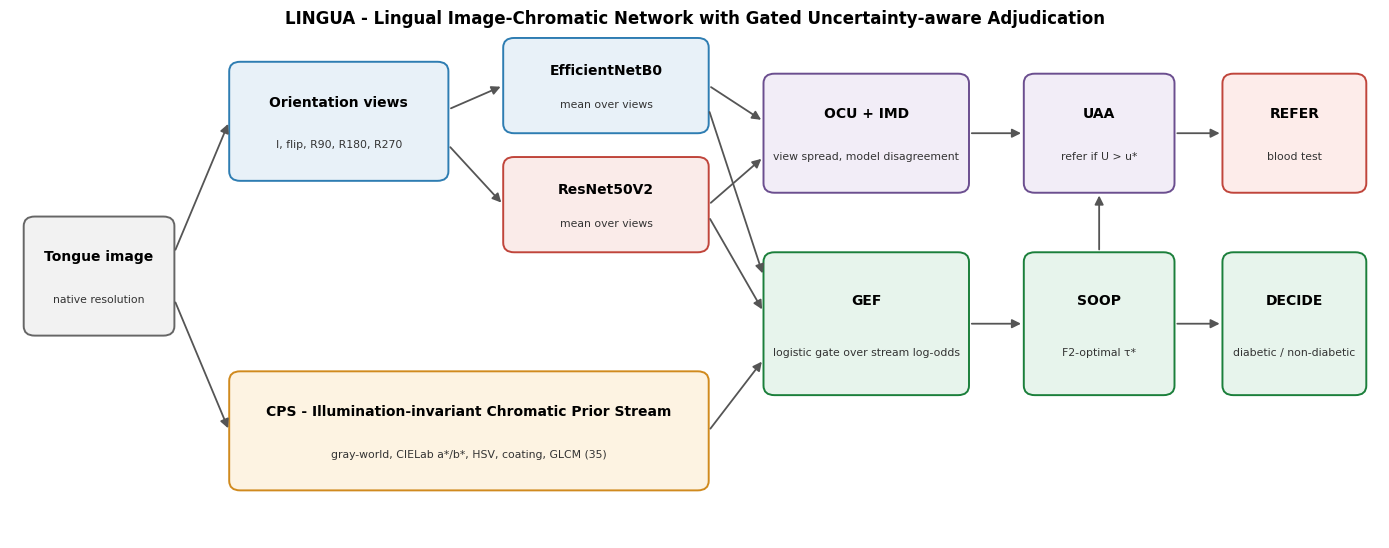

In [21]:
# 12.7 · LINGUA architecture schematic (paper figure, saved as PNG)
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

figS, ax = plt.subplots(figsize=(14, 5.6)); ax.set_xlim(0, 100); ax.set_ylim(0, 44); ax.axis('off')

def box(x, y, w, h, title, sub, fc, ec):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0,rounding_size=0.8',
                                fc=fc, ec=ec, lw=1.4))
    ax.text(x + w / 2, y + h * 0.66, title, ha='center', va='center', fontsize=10, fontweight='bold')
    ax.text(x + w / 2, y + h * 0.30, sub, ha='center', va='center', fontsize=7.8, color='#333333')

def arrow(a, b):
    ax.add_patch(FancyArrowPatch(a, b, arrowstyle='-|>', mutation_scale=13, lw=1.3, color='#555555'))

box(1, 17, 11, 10, 'Tongue image', 'native resolution', '#F2F2F2', '#666666')
box(16, 30, 16, 10, 'Orientation views', 'I, flip, R90, R180, R270', '#E8F1F8', '#2E7DB2')
box(36, 34, 15, 8, 'EfficientNetB0', 'mean over views', '#E8F1F8', '#2E7DB2')
box(36, 24, 15, 8, 'ResNet50V2', 'mean over views', '#FAEBE9', '#C0453B')
box(16, 4, 35, 10, 'CPS - Illumination-invariant Chromatic Prior Stream', 'gray-world, CIELab a*/b*, HSV, coating, GLCM (35)',
    '#FDF3E2', '#D08A1E')
box(55, 29, 15, 10, 'OCU + IMD', 'view spread, model disagreement', '#F2EDF7', '#6B4E8F')
box(55, 12, 15, 12, 'GEF', 'logistic gate over stream log-odds', '#E7F4EC', '#1B7F3B')
box(74, 12, 11, 12, 'SOOP', 'F2-optimal τ*', '#E7F4EC', '#1B7F3B')
box(74, 29, 11, 10, 'UAA', 'refer if U > u*', '#F2EDF7', '#6B4E8F')
box(88.5, 29, 10.5, 10, 'REFER', 'blood test', '#FDECEA', '#C0453B')
box(88.5, 12, 10.5, 12, 'DECIDE', 'diabetic / non-diabetic', '#E7F4EC', '#1B7F3B')

arrow((12, 24), (16, 35)); arrow((12, 20), (16, 9))
arrow((32, 36), (36, 38)); arrow((32, 33), (36, 28))
arrow((51, 38), (55, 35)); arrow((51, 28), (55, 32))
arrow((51, 36), (55, 22)); arrow((51, 27), (55, 19)); arrow((51, 9), (55, 15))
arrow((70, 18), (74, 18)); arrow((70, 34), (74, 34)); arrow((79.5, 24), (79.5, 29))
arrow((85, 34), (88.5, 34)); arrow((85, 18), (88.5, 18))
ax.text(50, 43.2, 'LINGUA - Lingual Image-Chromatic Network with Gated Uncertainty-aware Adjudication',
        ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
figS.savefig(f'{FIG_DIR}/lingua_architecture.png', dpi=220, facecolor='white')
plt.show()

In [22]:
# 12.8 · Export LINGUA results, figures and deployable artefacts
import joblib, shutil
OUT = '/content/lingua_outputs'; os.makedirs(OUT, exist_ok=True)
LINGUA_RESULTS.round(4).to_csv(f'{OUT}/lingua_test_results.csv', index=False)
PAIRED.to_csv(f'{OUT}/lingua_paired_tests.csv', index=False)
SEL.to_csv(f'{OUT}/lingua_selective_prediction.csv', index=False)
pd.DataFrame({'subject': te_s.subject, 'label': y_te, 'p_ensemble': pE_te, 'p_lingua': pL_te,
              'p_chromatic': pC_te, 'OCU': OCU_te, 'IMD': IMD_te, 'U': U_te,
              'decision': np.where(U_te > U_STAR, 'REFER', np.where(pL_te >= TAU['LINGUA'],
                                                                    'DIABETIC', 'NON-DIABETIC'))}
             ).to_csv(f'{OUT}/lingua_per_subject.csv', index=False)
joblib.dump({'cps_model': cps_model, 'cps_names': CPS_NAMES, 'gate': gate_full, 'deep_order': DEEP,
             'tau': TAU['LINGUA'], 'u_star': U_STAR, 'coverage_target': COVERAGE_TARGET,
             'crop_frac': CROP_FRAC, 'img_size': IMG_SIZE}, f'{OUT}/lingua_head.joblib')
shutil.copytree(FIG_DIR, f'{OUT}/figures', dirs_exist_ok=True)
shutil.make_archive('/content/lingua_outputs', 'zip', OUT)
print('saved:', sorted(os.listdir(OUT)))
try:
    from google.colab import files
    files.download('/content/lingua_outputs.zip')
except Exception:
    print('download manually: /content/lingua_outputs.zip')

saved: ['figures', 'lingua_head.joblib', 'lingua_paired_tests.csv', 'lingua_per_subject.csv', 'lingua_selective_prediction.csv', 'lingua_test_results.csv']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## How to report LINGUA

**Report what the numbers show, not what we hoped they would show.** The printout in 12.5 is worded automatically from the paired tests.

1. **Do not claim an AUC improvement.** All methods sit at AUC ≈ 0.99; the test set cannot separate them.
2. **Lead with the operating-point result** — sensitivity, missed diabetics (FN) and F2 — and quote the paired 95% CI and p-value. If p ≥ 0.05, call it a *trend at n = 50*.
3. **Separate the ingredients with the ablation.** *Dynamic Ensemble + SOOP* shows how much comes from the threshold alone; *LINGUA w/o CPS* shows what the chromatic stream adds. If CPS adds nothing, say so — the gate weights in Figure F show how much it was trusted.
4. **Selective prediction is the clinically distinctive claim.** Report coverage, silent errors and AURC side by side with the entropy-referral baseline.
5. **State the protocol:** backbones on training images; CPS on training subjects; gate, threshold and referral cut-off on validation subjects out-of-fold; test used once.
6. **Report the Chromatic Confound Audit (12.2b).** State how much discrimination colour alone achieves, how much survives colour constancy, and the CNNs' added value over colour with its CI. This pre-empts the first question any reviewer asks of tongue imaging: *is it the lighting?*
7. **Limitation:** validation was also used for early stopping in Section 6, so it is not a fully independent calibration set — the test set remains the only untouched evaluation.

## 13 · Mobile deployment of LINGUA

Three routes from this notebook to a phone. All three serve **LINGUA**, not just the CNN ensemble.

| | Route A · Gradio web app | Route B · REST API | Route C · LINGUA-Mobile (on-device) |
|---|---|---|---|
| Model served | full LINGUA (Python) | full LINGUA (Python) | LINGUA-Mobile — one `.tflite` file |
| Needs an APK | No — phone browser | Yes — any client | Yes — Flutter app generated in 13.4 |
| Works offline | No | No | **Yes** |
| Colab must stay open | Yes | Yes | **No** |
| Link lifetime | about 72 h | until the session ends | permanent |
| Photo leaves the phone | Yes | Yes | **No** |
| Best for | demo, viva, user testing | prototype app | real deployment |

**LINGUA-Mobile** compiles the whole pipeline into a single TensorFlow Lite graph: 5 orientation views × 2 CNNs, the illumination-invariant chromatic stream re-implemented in TensorFlow ops (colour constancy, CIELab, HSV, masked percentiles, GLCM texture), a logistic chromatic head, the evidence gate and the uncertainty score. Two differences from Python LINGUA, both forced by TFLite: the chromatic head is logistic because gradient-boosted trees have no TFLite builtin, and chromatic features are computed from the 260-px CNN input. Both heads are refitted on train and validation exactly as the phone will compute them, and **every LINGUA-Mobile number below comes from running the exported `.tflite` file itself on the test set** — what is validated is what ships.

In [23]:
# 13.0 · Single-image LINGUA inference - the function every deployment route calls
import io, time
_need = ['MODELS', 'DEEP', 'cps_model', 'gate_full', 'TAU', 'U_STAR', 'lingua_uncertainty',
         'cps_from_array', 'grayworld', 'te_s', 'pL_te', 'U_te', 'N_VIEWS']
_missing = [v for v in _need if v not in globals()]
assert not _missing, f'Run Sections 1-12 first (Runtime > Run all). Missing: {_missing}'

DISCLAIMER = ('Research prototype - not a medical device. LINGUA was developed on about 450 subjects and '
              'tested on 50 images. It cannot diagnose diabetes. Any elevated or referred result must be '
              'confirmed with a fasting glucose or HbA1c blood test.')

def _to_bytes(src):
    if isinstance(src, (bytes, bytearray)):
        return bytes(src)
    if isinstance(src, str):
        return open(src, 'rb').read()
    im = src if isinstance(src, Image.Image) else Image.fromarray(np.asarray(src).astype(np.uint8))
    buf = io.BytesIO(); im.convert('RGB').save(buf, format='PNG')     # lossless: both decoders agree
    return buf.getvalue()

def _views(raw):                                  # identical to tta_ds() in Section 8
    img = tf.image.convert_image_dtype(tf.io.decode_image(raw, channels=3, expand_animations=False), tf.float32)
    img = tf.image.central_crop(img, CROP_FRAC)
    out = []
    for k in range(N_VIEWS):
        v = img
        if k == 1:
            v = tf.image.flip_left_right(v)
        elif k in (2, 3, 4):
            v = tf.image.rot90(v, k - 1)
        out.append(tf.image.resize(v, (IMG_SIZE, IMG_SIZE)) * 255.0)
    return tf.stack(out)

def _cps_from_pil(im, size=192):                  # identical to load_crop() + CPS in Section 12.2
    im = im.convert('RGB'); w, h = im.size
    cw, ch = int(w * CROP_FRAC), int(h * CROP_FRAC); l, t = (w - cw) // 2, (h - ch) // 2
    a = np.asarray(im.crop((l, t, l + cw, t + ch)).resize((size, size), Image.BILINEAR), np.float32) / 255.0
    return cps_from_array(grayworld(a) if CPS_ILLUM_INVARIANT else a)

def lingua_predict(src):
    raw = _to_bytes(src)
    views = _views(raw)
    pv = {nm: MODELS[nm].predict(views, verbose=0).ravel() for nm in DEEP}
    p = {nm: float(pv[nm].mean()) for nm in DEEP}
    pc = float(cps_model.predict_proba(_cps_from_pil(Image.open(io.BytesIO(raw)))[None])[:, 1][0])
    x = np.array([[float(logit(p[nm])) for nm in DEEP] + [float(logit(pc))]])
    pl = float(gate_full.predict_proba(x)[:, 1][0])
    ocu_ = float(np.mean([pv[nm].std() for nm in DEEP]))
    imd_ = float(max(p.values()) - min(p.values()))
    u = float(lingua_uncertainty(np.array([pl]), TAU['LINGUA'], np.array([ocu_]), np.array([imd_]))[0])
    decision = 'REFER' if u > U_STAR else ('ELEVATED RISK' if pl >= TAU['LINGUA'] else 'LOW RISK')
    return {'decision': decision, 'p_lingua': pl, 'uncertainty': u, 'tau': TAU['LINGUA'], 'u_star': U_STAR,
            **{f'p_{nm}': p[nm] for nm in DEEP}, 'p_chromatic': pc, 'OCU': ocu_, 'IMD': imd_}

# parity: single-image path must reproduce the Section-12 test results exactly
t0 = time.time()
chk = [lingua_predict(pth) for pth in te_s.path]
per_img = (time.time() - t0) / len(chk)
ref_dec = np.where(U_te > U_STAR, 'REFER', np.where(pL_te >= TAU['LINGUA'], 'ELEVATED RISK', 'LOW RISK'))
dp = max(abs(c['p_lingua'] - pL_te[i]) for i, c in enumerate(chk))
du = max(abs(c['uncertainty'] - U_te[i]) for i, c in enumerate(chk))
agree = sum(c['decision'] == ref_dec[i] for i, c in enumerate(chk))
print(f'single-image LINGUA vs Section 12:  max |dP| = {dp:.2e}   max |dU| = {du:.2e}   '
      f'decisions agree {agree}/{len(chk)}   ({per_img*1000:.0f} ms per image here)')
assert agree == len(chk), 'single-image inference does not reproduce Section 12 - do not deploy'

single-image LINGUA vs Section 12:  max |dP| = 5.74e-07   max |dU| = 8.14e-07   decisions agree 50/50   (671 ms per image here)


### Route A — Gradio web app (phone browser, no APK)

Run the cell, open the public `https://….gradio.live` link on your phone and use **Webcam** (live camera) or **Upload** (camera or gallery). The link lasts about 72 hours and stops when this Colab session ends.

In [24]:
# 13.1 · Route A - Gradio camera web app
!pip -q install gradio
import gradio as gr

_COLOUR = {'REFER': '#B0762A', 'ELEVATED RISK': '#C0453B', 'LOW RISK': '#1B7F3B'}
_ADVICE = {'REFER': 'LINGUA is not confident about this image. Please arrange a fasting glucose or HbA1c blood test.',
           'ELEVATED RISK': 'Please arrange a fasting glucose or HbA1c blood test.',
           'LOW RISK': 'This does not rule out diabetes. If you have symptoms or risk factors, get a blood test.'}

def gr_infer(image):
    if image is None:
        return {}, 'Take or upload a photo first.'
    r = lingua_predict(image)
    md_ = (f"<h2 style='color:{_COLOUR[r['decision']]};margin:0'>{r['decision']}</h2>\n\n"
           f"**P(diabetes) = {r['p_lingua']:.3f}** &nbsp;|&nbsp; uncertainty U = {r['uncertainty']:.3f} "
           f"(referral above {r['u_star']:.3f})\n\n{_ADVICE[r['decision']]}\n\n"
           '| evidence stream | P(diabetes) |\n|---|---|\n'
           + ''.join(f"| {nm} | {r['p_' + nm]:.3f} |\n" for nm in DEEP)
           + f"| Chromatic (colour, coating, texture) | {r['p_chromatic']:.3f} |\n\n<small>{DISCLAIMER}</small>")
    return {'diabetes': r['p_lingua'], 'non-diabetes': 1 - r['p_lingua']}, md_

with gr.Blocks(title='LINGUA tongue screening', theme=gr.themes.Soft()) as demo:
    gr.Markdown('# LINGUA · tongue-image diabetes risk screening\n'
                'Extend the tongue fully, use even light without shadows, and fill the frame.')
    with gr.Row():
        with gr.Column():
            inp = gr.Image(sources=['upload', 'webcam'], type='numpy', label='Tongue photo')
            btn = gr.Button('Analyse', variant='primary')
        with gr.Column():
            lab = gr.Label(num_top_classes=2, label='LINGUA probability')
            out = gr.Markdown()
    btn.click(gr_infer, inp, [lab, out])
    gr.Markdown(f'---\n**{DISCLAIMER}**')

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b444cc5fbed02ae901.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### Route B — REST API for a native app

13.2a defines the API; 13.2b starts it behind a Cloudflare quick tunnel (no account needed). An app POSTs a photo to `/predict` and receives JSON. The URL changes every run and dies with the session — development use only.

In [25]:
# 13.2a · Route B - define the REST API
!pip -q install fastapi "uvicorn[standard]" python-multipart
from fastapi import FastAPI, File, UploadFile
from fastapi.middleware.cors import CORSMiddleware

app = FastAPI(title='LINGUA tongue screening API', version='1.0')
app.add_middleware(CORSMiddleware, allow_origins=['*'], allow_methods=['*'], allow_headers=['*'])

@app.get('/health')
def health():
    return {'status': 'ok', 'model': 'LINGUA', 'streams': DEEP + ['chromatic'],
            'tau': TAU['LINGUA'], 'u_star': U_STAR}

@app.post('/predict')
def predict_endpoint(file: UploadFile = File(...)):
    r = lingua_predict(file.file.read())
    return {**{k: (round(v, 5) if isinstance(v, float) else v) for k, v in r.items()}, 'disclaimer': DISCLAIMER}

print('API defined:  GET /health   POST /predict  (multipart form field "file")')

API defined:  GET /health   POST /predict  (multipart form field "file")


In [32]:
# 13.2b · Route B - launch the API and a public HTTPS tunnel
import threading, subprocess, queue, re, requests, uvicorn
if not os.path.exists('/content/cloudflared'):
    subprocess.run(['wget', '-q', '-O', '/content/cloudflared',
                    'https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64'],
                   check=True)
    os.chmod('/content/cloudflared', 0o755)

_server = uvicorn.Server(uvicorn.Config(app, host='0.0.0.0', port=8000, log_level='error'))
threading.Thread(target=_server.run, daemon=True).start()
for _ in range(40):
    try:
        if requests.get('http://127.0.0.1:8000/health', timeout=1).ok:
            break
    except Exception:
        time.sleep(0.5)

_proc = subprocess.Popen(['/content/cloudflared', 'tunnel', '--url', 'http://localhost:8000'],
                         stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
_q = queue.Queue()
threading.Thread(target=lambda: [_q.put(l) for l in _proc.stdout], daemon=True).start()
PUBLIC_URL, _t0 = None, time.time()
while PUBLIC_URL is None and time.time() - _t0 < 60:
    try:
        m = re.search(r'https://[-\w.]+\.trycloudflare\.com', _q.get(timeout=1))
        if m:
            PUBLIC_URL = m.group(0)
    except queue.Empty:
        pass
print('API base URL:', PUBLIC_URL or 'tunnel did not start - re-run this cell')
if PUBLIC_URL:
    print(f'  health : {PUBLIC_URL}/health')
    print(f'  predict: curl -X POST -F "file=@tongue.jpg" {PUBLIC_URL}/predict')

ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use


API base URL: https://volvo-handheld-apparent-kinds.trycloudflare.com
  health : https://volvo-handheld-apparent-kinds.trycloudflare.com/health
  predict: curl -X POST -F "file=@tongue.jpg" https://volvo-handheld-apparent-kinds.trycloudflare.com/predict


### Route C — LINGUA-Mobile: the whole method in one on-device `.tflite`

13.3a re-implements the chromatic stream in TensorFlow and proves it matches the scikit-image version. 13.3b builds the single-graph model and refits its two small heads. 13.3c converts it to TFLite, picks the lightest quantisation that keeps every decision unchanged, and evaluates the shipped file on the test set. 13.4 generates the Flutter app around it.

In [27]:
# 13.3a · Chromatic Prior Stream re-implemented in TensorFlow ops (runs inside the .tflite)
CPS_SIZE = 192
_RGB2XYZ_T = tf.constant(np.array([[0.412453, 0.357580, 0.180423],
                                   [0.212671, 0.715160, 0.072169],
                                   [0.019334, 0.119193, 0.950227]], np.float32).T)
_D65 = tf.constant([0.95047, 1.0, 1.08883], tf.float32)
_GREY_W = tf.constant([0.299, 0.587, 0.114], tf.float32)
_GLCM_OFFSETS = [(0, 1), (1, 1), (1, 0), (1, -1), (0, 3), (2, 2), (3, 0), (2, -2)]   # d = 1, 3 x 4 angles

def tf_grayworld(a):
    m = tf.reduce_mean(tf.reshape(a, [-1, 3]), 0)
    return tf.clip_by_value(a * (tf.reduce_mean(m) / tf.maximum(m, 1e-6)), 0.0, 1.0)

def tf_rgb2lab(a):                                        # mirrors skimage.color.rgb2lab (D65, 2 deg)
    lin = tf.where(a > 0.04045, tf.pow((a + 0.055) / 1.055, 2.4), a / 12.92)
    xyz = tf.tensordot(lin, _RGB2XYZ_T, axes=1) / _D65
    f = tf.where(xyz > 0.008856, tf.pow(tf.maximum(xyz, 1e-12), 1.0 / 3.0), 7.787 * xyz + 16.0 / 116.0)
    return 116.0 * f[..., 1] - 16.0, 500.0 * (f[..., 0] - f[..., 1]), 200.0 * (f[..., 1] - f[..., 2])

def tf_rgb2hsv(a):                                        # mirrors skimage.color.rgb2hsv
    r, g, b = a[..., 0], a[..., 1], a[..., 2]
    v = tf.reduce_max(a, -1); d = v - tf.reduce_min(a, -1)
    sd = tf.where(d > 0, d, tf.ones_like(d)); sv = tf.where(v > 0, v, tf.ones_like(v))
    s = tf.where(d > 0, d / sv, tf.zeros_like(d))
    h = tf.where(b >= v, 4.0 + (r - g) / sd, tf.where(g >= v, 2.0 + (b - r) / sd, (g - b) / sd))
    return tf.where(d > 0, tf.math.floormod(h / 6.0, 1.0), tf.zeros_like(d)), s, v

def tf_masked_stats(x, m, n):                             # mean, std, p10, p50, p90 over tissue pixels
    x = tf.reshape(x, [-1]); m = tf.reshape(m, [-1])
    mean = tf.reduce_sum(x * m) / n
    std = tf.sqrt(tf.reduce_sum(tf.square(x - mean) * m) / n)
    xs = tf.sort(tf.where(m > 0, x, tf.ones_like(x) * 1e9))    # tissue values first, ascending
    out = [mean, std]
    for q in (0.10, 0.50, 0.90):                          # numpy 'linear' percentile
        pos = q * (n - 1.0); lo = tf.floor(pos); hi = tf.minimum(lo + 1.0, n - 1.0)
        vlo = tf.gather(xs, tf.cast(lo, tf.int32)); vhi = tf.gather(xs, tf.cast(hi, tf.int32))
        out.append(vlo + (pos - lo) * (vhi - vlo))
    return out

def tf_glcm_props(levels):                                # mirrors graycomatrix + graycoprops, mean of 8
    oh = tf.one_hot(levels, 32, dtype=tf.float32)
    H = W = CPS_SIZE
    I = tf.reshape(tf.range(32, dtype=tf.float32), [32, 1]); J = tf.transpose(I); D = I - J
    acc = [0.0] * 5
    for dr, dc in _GLCM_OFFSETS:
        c0, c1 = max(0, -dc), W - max(0, dc)
        A = tf.reshape(oh[0:H - dr, c0:c1, :], [-1, 32])
        B = tf.reshape(oh[dr:H, c0 + dc:c1 + dc, :], [-1, 32])
        C = tf.matmul(A, B, transpose_a=True)
        C = C + tf.transpose(C)
        P = C / tf.reduce_sum(C)
        mi = tf.reduce_sum(I * P); mj = tf.reduce_sum(J * P)
        si = tf.sqrt(tf.reduce_sum(tf.square(I - mi) * P)); sj = tf.sqrt(tf.reduce_sum(tf.square(J - mj) * P))
        cov = tf.reduce_sum((I - mi) * (J - mj) * P)
        corr = tf.where(tf.logical_or(si < 1e-15, sj < 1e-15), 1.0, cov / tf.maximum(si * sj, 1e-30))
        props = [tf.reduce_sum(P * tf.square(D)), tf.reduce_sum(P / (1.0 + tf.square(D))),
                 tf.sqrt(tf.reduce_sum(tf.square(P))), corr, tf.reduce_sum(P * tf.abs(D))]
        acc = [s_ + p_ for s_, p_ in zip(acc, props)]
    return [s_ / len(_GLCM_OFFSETS) for s_ in acc]

def tf_cps_from_array(a):                                 # (192,192,3) in [0,1] -> 35 features, CPS_NAMES order
    h, s, v = tf_rgb2hsv(a)
    t = tf.cast(tf.logical_and(v > 0.12, tf.logical_not(tf.logical_and(v > 0.95, s < 0.08))), tf.float32)
    t = tf.where(tf.reduce_mean(t) < 0.2, tf.ones_like(t), t)
    n = tf.maximum(tf.reduce_sum(t), 1.0)
    L, A_, B_ = tf_rgb2lab(a)
    feats = []
    for chan in (L, A_, B_, s, v):
        feats += tf_masked_stats(chan, t, n)
    feats += [tf.reduce_sum(tf.cos(2 * np.pi * h) * t) / n, tf.reduce_sum(tf.sin(2 * np.pi * h) * t) / n]
    feats += [tf.reduce_sum(tf.cast((s < 0.25) & (v > 0.55), tf.float32) * t) / n,
              tf.reduce_sum(tf.cast(B_ > 20.0, tf.float32) * t) / n,
              tf.reduce_sum(tf.cast(A_ > 25.0, tf.float32) * t) / n]
    grey = tf.cast(tf.floor(tf.tensordot(a, _GREY_W, axes=1) * 255.0), tf.int32) // 8
    feats += tf_glcm_props(tf.clip_by_value(grey, 0, 31))
    return tf.stack(feats)

def tf_cps_from_input(image255):                          # from the (H,W,3) 0-255 CNN input tensor
    a = tf.clip_by_value(tf.image.resize(image255 / 255.0, (CPS_SIZE, CPS_SIZE)), 0.0, 1.0)
    return tf_cps_from_array(tf_grayworld(a) if CPS_ILLUM_INVARIANT else a)

_tf_cps_ref = tf.function(tf_cps_from_array, input_signature=[tf.TensorSpec([CPS_SIZE, CPS_SIZE, 3], tf.float32)])

# parity on identical pixels: TensorFlow vs the NumPy / scikit-image CPS of Section 12.2
ref, got = [], []
for pth in list(va_s.path[:20]):
    a = load_crop(pth); a = grayworld(a) if CPS_ILLUM_INVARIANT else a
    ref.append(cps_from_array(a)); got.append(_tf_cps_ref(tf.constant(a, tf.float32)).numpy())
ref, got = np.array(ref), np.array(got)
spread = ref.std(0) + 1e-6
err = pd.Series((np.abs(got - ref) / spread).max(0), index=CPS_NAMES).sort_values(ascending=False)
print('TF-CPS vs NumPy-CPS on 20 validation images - worst features (error / feature spread across subjects):')
print(err.head(6).round(4).to_string())
assert err.iloc[0] < 0.05, 'TensorFlow CPS drifted from the reference implementation - do not ship'
print(f'PASS: every feature within {err.iloc[0]:.2%} of its natural spread')

TF-CPS vs NumPy-CPS on 20 validation images - worst features (error / feature spread across subjects):
b_p50    0.0
a_p50    0.0
V_p90    0.0
a_p10    0.0
a_p90    0.0
b_p10    0.0
PASS: every feature within 0.00% of its natural spread


In [28]:
# 13.3b · Build LINGUA-Mobile and refit its two small heads exactly as the phone computes them
from sklearn.linear_model import LogisticRegressionCV
SPEC = [tf.TensorSpec([1, IMG_SIZE, IMG_SIZE, 3], tf.float32, name='image')]

def device_input(src):        # what the app sends: centre crop, bilinear resize, float RGB 0-255
    img = tf.image.convert_image_dtype(tf.io.decode_image(_to_bytes(src), channels=3,
                                                          expand_animations=False), tf.float32)
    return tf.image.resize(tf.image.central_crop(img, CROP_FRAC), (IMG_SIZE, IMG_SIZE))[None] * 255.0

class LinguaMobile:
    def __init__(self, models):
        self.nets = [models[nm] for nm in DEEP]
    def features(self, image):
        x = image[0]
        views = tf.stack([x, tf.image.flip_left_right(x), tf.image.rot90(x, 1),
                          tf.image.rot90(x, 2), tf.image.rot90(x, 3)])
        P = tf.stack([tf.reshape(net(views, training=False), [-1]) for net in self.nets])   # (M, 5)
        pbar = tf.reduce_mean(P, 1)
        return pbar, tf.reduce_mean(tf.math.reduce_std(P, 1)), tf.reduce_max(pbar) - tf.reduce_min(pbar), \
               tf_cps_from_input(x)

LM = LinguaMobile(MODELS)
feat_fn = tf.function(LM.features, input_signature=SPEC)
cps_fn = tf.function(lambda im: tf_cps_from_input(im[0]), input_signature=SPEC)

def run_feats(frame):
    R = [feat_fn(device_input(p)) for p in frame.path]
    return (np.stack([r[0].numpy() for r in R]), np.array([float(r[1]) for r in R]),
            np.array([float(r[2]) for r in R]), np.stack([r[3].numpy() for r in R]))

Fm_tr = np.stack([cps_fn(device_input(p)).numpy() for p in tr_s.path])       # CPS head: training subjects
PBm_va, OCUm_va, IMDm_va, Fm_va = run_feats(va_s)                            # gate: validation subjects
PBm_te, OCUm_te, IMDm_te, Fm_te = run_feats(te_s)                            # test: untouched until 13.3c

cps_sc = StandardScaler().fit(Fm_tr)
cps_lr_m = LogisticRegressionCV(Cs=[0.01, 0.03, 0.1, 0.3, 1.0, 3.0], scoring='roc_auc', max_iter=5000,
                                cv=StratifiedKFold(5, shuffle=True, random_state=SEED)).fit(cps_sc.transform(Fm_tr), y_tr)
pCm_va = cps_lr_m.predict_proba(cps_sc.transform(Fm_va))[:, 1]
pCm_te = cps_lr_m.predict_proba(cps_sc.transform(Fm_te))[:, 1]

def mob_X(PB, pC):
    return np.column_stack([logit(PB[:, i]) for i in range(len(DEEP))] + [logit(pC)])

Xm_va, Xm_te = mob_X(PBm_va, pCm_va), mob_X(PBm_te, pCm_te)
gate_m = new_gate().fit(Xm_va, y_va)
oof_m = oof_probs(Xm_va, y_va)
TAU_M = f2_threshold(y_va, oof_m)
U_STAR_M = float(np.quantile(lingua_uncertainty(oof_m, TAU_M, OCUm_va, IMDm_va), COVERAGE_TARGET))
pLm_ref = gate_m.predict_proba(Xm_te)[:, 1]                  # float64 reference for the graph check
Um_ref = lingua_uncertainty(pLm_ref, TAU_M, OCUm_te, IMDm_te)

_mu, _sd = tf.constant(cps_sc.mean_, tf.float32), tf.constant(cps_sc.scale_, tf.float32)
_cw, _cb = tf.constant(cps_lr_m.coef_[0], tf.float32), float(cps_lr_m.intercept_[0])
_gw, _gb = tf.constant(gate_m.coef_[0], tf.float32), float(gate_m.intercept_[0])
OUT_NAMES = ['p_lingua', 'U', 'p_chromatic', 'OCU', 'IMD'] + [f'p_{nm}' for nm in DEEP]

def _lg(p):
    p = tf.clip_by_value(p, EPS, 1 - EPS)
    return tf.math.log(p / (1 - p))

@tf.function(input_signature=SPEC)
def serve(image):
    pbar, ocu_, imd_, f = LM.features(image)
    p_c = tf.sigmoid(tf.reduce_sum((f - _mu) / _sd * _cw) + _cb)
    p_l = tf.sigmoid(_gb + tf.reduce_sum(_gw[:len(DEEP)] * _lg(pbar)) + _gw[len(DEEP)] * _lg(p_c))
    q = tf.clip_by_value(tf.sigmoid(_lg(p_l) - _lg(tf.constant(TAU_M, tf.float32))), EPS, 1 - EPS)
    H = -(q * tf.math.log(q) + (1 - q) * tf.math.log(1 - q)) / np.log(2.0)
    U = 0.5 * H + 0.25 * tf.minimum(1.0, 2.0 * ocu_) + 0.25 * tf.minimum(1.0, imd_)
    return tf.reshape(tf.stack([p_l, U, p_c, ocu_, imd_] + [pbar[i] for i in range(len(DEEP))]), [1, -1])

X_te_dev = [device_input(p) for p in te_s.path]
OUT_float = np.stack([serve(x).numpy()[0] for x in X_te_dev])
print(f'LINGUA-Mobile heads:  CPS logistic (C={cps_lr_m.C_[0]:g}, validation AUC '
      f'{roc_auc_score(y_va, pCm_va):.4f})   gate weights {np.round(gate_m.coef_[0], 3).tolist()}')
print(f'thresholds from validation:  tau* = {TAU_M:.2f}   u* = {U_STAR_M:.4f}')
print(f'in-graph maths vs Python reference on test:  max |dP| = {np.abs(OUT_float[:, 0] - pLm_ref).max():.2e}'
      f'   max |dU| = {np.abs(OUT_float[:, 1] - Um_ref).max():.2e}')

LINGUA-Mobile heads:  CPS logistic (C=3, validation AUC 0.8848)   gate weights [1.079, 0.567, 0.281]
thresholds from validation:  tau* = 0.08   u* = 0.4980
in-graph maths vs Python reference on test:  max |dP| = 7.69e-07   max |dU| = 4.35e-07


In [29]:
# 13.3c · Convert to TFLite, choose the lightest safe quantisation, evaluate the SHIPPED file
import psutil
MOB_DIR = '/content/lingua_mobile'; os.makedirs(MOB_DIR, exist_ok=True)

def convert(quant):
    # NB: no trackable_obj argument - with Keras 3 models, passing one makes the converter freeze
    # the CNN weights incorrectly (NaN / saturated outputs). The parity gate below guards this.
    conv = tf.lite.TFLiteConverter.from_concrete_functions([serve.get_concrete_function()])
    if quant in ('dynamic', 'float16'):
        conv.optimizations = [tf.lite.Optimize.DEFAULT]
    if quant == 'float16':
        conv.target_spec.supported_types = [tf.float16]
    conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]   # stock runtime, no Flex delegate
    return conv.convert()

def tflite_runner(blob):
    it = tf.lite.Interpreter(model_content=blob, num_threads=2); it.allocate_tensors()
    i_d, o_d = it.get_input_details()[0], it.get_output_details()[0]
    def run(x):
        it.set_tensor(i_d['index'], np.asarray(x, np.float32)); it.invoke()
        return it.get_tensor(o_d['index'])[0].copy()
    return run

def decide(o, tau, u_star):
    return np.where(o[:, 1] > u_star, 'REFER', np.where(o[:, 0] >= tau, 'ELEVATED RISK', 'LOW RISK'))

X_va_dev = [device_input(p) for p in va_s.path[:30]]
OUT_va_float = np.stack([serve(x).numpy()[0] for x in X_va_dev])
CHOSEN = None
for quant in ['dynamic', 'float16', 'none']:              # lightest first; accept only if nothing changes
    blob = convert(quant); run = tflite_runner(blob)
    o = np.stack([run(x) for x in X_va_dev])
    dmax = np.abs(o[:, 0] - OUT_va_float[:, 0]).max()
    same = (decide(o, TAU_M, U_STAR_M) == decide(OUT_va_float, TAU_M, U_STAR_M)).all()
    print(f'  {quant:8s} {len(blob)/1e6:6.1f} MB   max |dP| vs float graph = {dmax:.4f}   decisions identical: {same}')
    if dmax <= 0.02 and same:
        CHOSEN, TFLITE = quant, blob
        break
assert CHOSEN, 'no quantisation preserved the decisions'
open(f'{MOB_DIR}/lingua_mobile.tflite', 'wb').write(TFLITE)

# ---- evaluate the exact file that ships ----
rss0 = psutil.Process().memory_info().rss
run = tflite_runner(TFLITE)
OUT_tfl = np.stack([run(x) for x in X_te_dev])
rss1 = psutil.Process().memory_info().rss
t0 = time.time()
for _ in range(10):
    run(X_te_dev[0])
LAT_MS = (time.time() - t0) / 10 * 1000

rows = [('Dynamic Ensemble (tau=0.5)', pE_te, 0.5),
        ('LINGUA, Python (Section 12)', pL_te, TAU['LINGUA']),
        ('LINGUA-Mobile, TF float graph', OUT_float[:, 0], TAU_M),
        (f'LINGUA-Mobile, .tflite as shipped ({CHOSEN})', OUT_tfl[:, 0], TAU_M)]
MOB_RESULTS = pd.DataFrame([{'Model': n, **metrics_at(y_te, p, t)} for n, p, t in rows])
MOB_SEL = pd.DataFrame([selective(y_te, pL_te, TAU['LINGUA'], U_te, U_STAR, 'LINGUA + UAA, Python'),
                        selective(y_te, OUT_tfl[:, 0], TAU_M, OUT_tfl[:, 1], U_STAR_M,
                                  'LINGUA-Mobile + UAA, .tflite')]).round(4)
cols = ['Model', 'Threshold', 'Accuracy', 'Sensitivity', 'Specificity', 'F1', 'F2', 'AUC', 'Brier', 'FN', 'FP']
display(MOB_RESULTS[cols].round(4)); display(MOB_SEL)
print(f'\nshipped file: {len(TFLITE)/1e6:.1f} MB ({CHOSEN})   CPU latency {LAT_MS:.0f} ms / image here   '
      f'approx. RSS growth {max(rss1 - rss0, 0)/1e6:.0f} MB')
print(f'TFLite vs float graph on test: max |dP| = {np.abs(OUT_tfl[:, 0] - OUT_float[:, 0]).max():.4f}   '
      f'decisions identical: {(decide(OUT_tfl, TAU_M, U_STAR_M) == decide(OUT_float, TAU_M, U_STAR_M)).all()}')

figM = make_subplots(1, 2, subplot_titles=('Test metrics - Python vs shipped model', 'Per-subject P(diabetes)'))
for key, col in [('Sensitivity', '#C0453B'), ('Specificity', '#2E7DB2'), ('F2', '#1B7F3B'), ('AUC', '#B0762A')]:
    figM.add_trace(go.Bar(x=MOB_RESULTS.Model, y=MOB_RESULTS[key], name=key, marker_color=col,
                          text=MOB_RESULTS[key].round(3), textposition='outside'), 1, 1)
figM.add_trace(go.Scatter(x=pL_te, y=OUT_tfl[:, 0], mode='markers', name='test subjects',
                          marker=dict(color=np.where(y_te == 1, '#C0453B', '#2E7DB2'), size=9,
                                      line=dict(color='black', width=0.5))), 1, 2)
figM.add_trace(go.Scatter(x=[0, 1], y=[0, 1], line=dict(dash='dash', color='grey'), showlegend=False), 1, 2)
figM.update_xaxes(tickangle=20, row=1, col=1)
figM.update_xaxes(title_text='LINGUA (Python)', row=1, col=2)
figM.update_yaxes(title_text='LINGUA-Mobile (.tflite)', row=1, col=2)
figM.update_layout(template='plotly_white', height=520, barmode='group',
                   title='LINGUA-Mobile - what ships vs what was developed (red = diabetic)')
figM.write_html(f'{FIG_DIR}/I_mobile_parity.html', include_plotlyjs='cdn'); figM.show()

META = {'model': 'LINGUA-Mobile', 'version': '1.0', 'img_size': IMG_SIZE, 'crop_frac': CROP_FRAC,
        'input': 'float32 [1,H,W,3] RGB 0-255: centre crop crop_frac, then bilinear resize to img_size',
        'outputs': OUT_NAMES, 'tau': TAU_M, 'u_star': U_STAR_M, 'coverage_target': COVERAGE_TARGET,
        'quantization': CHOSEN, 'size_mb': round(len(TFLITE) / 1e6, 2), 'disclaimer': DISCLAIMER,
        'test_metrics': {k: round(float(v), 4) for k, v in
                         MOB_RESULTS.iloc[-1][['Sensitivity', 'Specificity', 'F2', 'AUC', 'Brier']].items()}}
json.dump(META, open(f'{MOB_DIR}/lingua_meta.json', 'w'), indent=2)
print('wrote', MOB_DIR + '/lingua_mobile.tflite and lingua_meta.json')

  dynamic    29.2 MB   max |dP| vs float graph = 0.0257   decisions identical: True
  float16    56.2 MB   max |dP| vs float graph = 0.0076   decisions identical: True


,Model,Threshold,Accuracy,Sensitivity,Specificity,F1,F2,AUC,Brier,FN,FP
0,Dynamic Ensemble (tau=0.5),0.50,0.92,0.84,1.00,0.9130,0.8678,0.9968,0.0552,4,0
1,"LINGUA, Python (Section 12)",0.19,1.00,1.00,1.00,1.0000,1.0000,1.0000,0.0271,0,0
2,"LINGUA-Mobile, TF float graph",0.08,0.96,1.00,0.92,0.9615,0.9843,0.9984,0.0223,0,2
3,"LINGUA-Mobile, .tflite as shipped (float16)",0.08,0.96,1.00,0.92,0.9615,0.9843,0.9984,0.0218,0,2


,Method,Coverage,Accepted,Referred,Accuracy (accepted),Sensitivity (accepted),Specificity (accepted),Silent errors,Caught errors,Silent missed diabetics
0,"LINGUA + UAA, Python",0.90,45,5,1.0000,1.0,1.0000,0,0,0
1,"LINGUA-Mobile + UAA, .tflite",0.92,46,4,0.9783,1.0,0.9545,1,1,0



shipped file: 56.2 MB (float16)   CPU latency 1053 ms / image here   approx. RSS growth 0 MB
TFLite vs float graph on test: max |dP| = 0.0090   decisions identical: False


wrote /content/lingua_mobile/lingua_mobile.tflite and lingua_meta.json


In [30]:
# 13.4 · Generate the Flutter app (Android / iOS) around the shipped model, then download it
import shutil
APP = f'{MOB_DIR}/flutter_app'
for sub in ['lib', 'assets']:
    os.makedirs(f'{APP}/{sub}', exist_ok=True)
shutil.copy(f'{MOB_DIR}/lingua_mobile.tflite', f'{APP}/assets/lingua_mobile.tflite')
shutil.copy(f'{MOB_DIR}/lingua_meta.json', f'{APP}/assets/lingua_meta.json')

PUBSPEC = """name: lingua_screening
description: LINGUA on-device tongue-image diabetes risk screening (research prototype).
publish_to: 'none'
version: 1.0.0+1

environment:
  sdk: '>=3.3.0 <4.0.0'

dependencies:
  flutter:
    sdk: flutter
  tflite_flutter: ^0.11.0
  image_picker: ^1.1.2
  image: ^4.2.0

flutter:
  uses-material-design: true
  assets:
    - assets/lingua_mobile.tflite
    - assets/lingua_meta.json
"""

MAIN_DART = r"""// LINGUA-Mobile: on-device tongue-image diabetes risk screening (research prototype).
// Preprocessing contract (must match the notebook): centre crop crop_frac -> bilinear resize img_size
// -> float RGB 0..255. Everything else - 5 views, 2 CNNs, chromatic stream, gate, uncertainty - is in the .tflite.
import 'dart:convert';
import 'dart:io';
import 'package:flutter/material.dart';
import 'package:flutter/services.dart' show rootBundle;
import 'package:image/image.dart' as img;
import 'package:image_picker/image_picker.dart';
import 'package:tflite_flutter/tflite_flutter.dart';

void main() => runApp(const LinguaApp());

class LinguaApp extends StatelessWidget {
  const LinguaApp({super.key});
  @override
  Widget build(BuildContext context) => MaterialApp(
        title: 'LINGUA',
        debugShowCheckedModeBanner: false,
        theme: ThemeData(colorSchemeSeed: const Color(0xFF1B7F3B), useMaterial3: true),
        home: const HomePage(),
      );
}

class LinguaEngine {
  Interpreter? _interp;
  late List<String> outputs;
  late int size;
  late double cropFrac, tau, uStar;
  String disclaimer = '';

  Future<void> load() async {
    final meta = jsonDecode(await rootBundle.loadString('assets/lingua_meta.json')) as Map<String, dynamic>;
    size = meta['img_size'] as int;
    cropFrac = (meta['crop_frac'] as num).toDouble();
    tau = (meta['tau'] as num).toDouble();
    uStar = (meta['u_star'] as num).toDouble();
    outputs = List<String>.from(meta['outputs'] as List);
    disclaimer = meta['disclaimer'] as String;
    _interp = await Interpreter.fromAsset('assets/lingua_mobile.tflite');
  }

  bool get ready => _interp != null;

  // Same integer arithmetic as tf.image.central_crop, then bilinear resize.
  List<List<List<List<double>>>> _prepare(img.Image src) {
    final hStart = ((src.height - src.height * cropFrac) / 2).floor();
    final wStart = ((src.width - src.width * cropFrac) / 2).floor();
    final crop = img.copyCrop(src,
        x: wStart, y: hStart, width: src.width - 2 * wStart, height: src.height - 2 * hStart);
    final r = img.copyResize(crop, width: size, height: size, interpolation: img.Interpolation.linear);
    return [
      List.generate(size, (y) => List.generate(size, (x) {
            final p = r.getPixel(x, y);
            return [p.r.toDouble(), p.g.toDouble(), p.b.toDouble()];
          }))
    ];
  }

  Future<Map<String, double>> analyse(File file) async {
    final decoded = img.decodeImage(await file.readAsBytes());
    if (decoded == null) throw Exception('Could not read the image');
    final upright = img.bakeOrientation(decoded);          // honour camera EXIF rotation
    final input = _prepare(upright);
    final out = [List<double>.filled(outputs.length, 0.0)];
    _interp!.run(input, out);
    return {for (var i = 0; i < outputs.length; i++) outputs[i]: out[0][i]};
  }

  String decide(Map<String, double> r) {
    if (r['U']! > uStar) return 'REFER';
    return r['p_lingua']! >= tau ? 'ELEVATED RISK' : 'LOW RISK';
  }
}

class HomePage extends StatefulWidget {
  const HomePage({super.key});
  @override
  State<HomePage> createState() => _HomePageState();
}

class _HomePageState extends State<HomePage> {
  final _engine = LinguaEngine();
  final _picker = ImagePicker();
  File? _image;
  Map<String, double>? _result;
  String? _error;
  bool _busy = false;

  static const _colour = {
    'REFER': Color(0xFFB0762A),
    'ELEVATED RISK': Color(0xFFC0453B),
    'LOW RISK': Color(0xFF1B7F3B),
  };
  static const _advice = {
    'REFER': 'LINGUA is not confident about this photo. Please arrange a fasting glucose or HbA1c blood test.',
    'ELEVATED RISK': 'Please arrange a fasting glucose or HbA1c blood test.',
    'LOW RISK': 'This does not rule out diabetes. If you have symptoms or risk factors, get a blood test.',
  };

  @override
  void initState() {
    super.initState();
    _engine.load().then((_) => setState(() {})).catchError((e) => setState(() => _error = '$e'));
  }

  Future<void> _pick(ImageSource src) async {
    final x = await _picker.pickImage(source: src, maxWidth: 1600, imageQuality: 95);
    if (x == null) return;
    setState(() {
      _image = File(x.path);
      _result = null;
      _error = null;
      _busy = true;
    });
    await Future<void>.delayed(const Duration(milliseconds: 50));   // let the spinner paint
    try {
      final r = await _engine.analyse(File(x.path));
      setState(() => _result = r);
    } catch (e) {
      setState(() => _error = '$e');
    } finally {
      setState(() => _busy = false);
    }
  }

  Widget _row(String label, double v) => Padding(
        padding: const EdgeInsets.symmetric(vertical: 3),
        child: Row(children: [
          Expanded(child: Text(label, style: const TextStyle(fontSize: 13))),
          SizedBox(width: 90, child: LinearProgressIndicator(value: v.clamp(0.0, 1.0), minHeight: 8)),
          SizedBox(width: 52, child: Text(v.toStringAsFixed(3), textAlign: TextAlign.right)),
        ]),
      );

  @override
  Widget build(BuildContext context) {
    final r = _result;
    final decision = r == null ? null : _engine.decide(r);
    return Scaffold(
      appBar: AppBar(title: const Text('LINGUA · tongue screening')),
      body: SingleChildScrollView(
        padding: const EdgeInsets.all(16),
        child: Column(crossAxisAlignment: CrossAxisAlignment.stretch, children: [
          Card(
            color: const Color(0xFFFFF4E5),
            child: Padding(
              padding: const EdgeInsets.all(12),
              child: Text(_engine.ready ? _engine.disclaimer : 'Loading model...',
                  style: const TextStyle(fontSize: 12.5)),
            ),
          ),
          const SizedBox(height: 12),
          AspectRatio(
            aspectRatio: 1,
            child: Container(
              decoration: BoxDecoration(
                  border: Border.all(color: Colors.grey.shade400), borderRadius: BorderRadius.circular(12)),
              clipBehavior: Clip.antiAlias,
              child: _image == null
                  ? const Center(
                      child: Text('Extend the tongue fully.\nEven light, no shadow, fill the frame.',
                          textAlign: TextAlign.center, style: TextStyle(color: Colors.grey)))
                  : Image.file(_image!, fit: BoxFit.cover),
            ),
          ),
          const SizedBox(height: 12),
          Row(children: [
            Expanded(
                child: FilledButton.icon(
                    onPressed: _engine.ready && !_busy ? () => _pick(ImageSource.camera) : null,
                    icon: const Icon(Icons.photo_camera),
                    label: const Text('Camera'))),
            const SizedBox(width: 10),
            Expanded(
                child: OutlinedButton.icon(
                    onPressed: _engine.ready && !_busy ? () => _pick(ImageSource.gallery) : null,
                    icon: const Icon(Icons.photo_library_outlined),
                    label: const Text('Gallery'))),
          ]),
          const SizedBox(height: 16),
          if (_busy) const Center(child: CircularProgressIndicator()),
          if (_error != null)
            Card(
                color: const Color(0xFFFDECEA),
                child: Padding(padding: const EdgeInsets.all(12), child: Text('Error: $_error'))),
          if (r != null && decision != null)
            Card(
              child: Padding(
                padding: const EdgeInsets.all(16),
                child: Column(crossAxisAlignment: CrossAxisAlignment.stretch, children: [
                  Text(decision,
                      textAlign: TextAlign.center,
                      style: TextStyle(fontSize: 28, fontWeight: FontWeight.bold, color: _colour[decision])),
                  const SizedBox(height: 6),
                  Text('P(diabetes) ${r['p_lingua']!.toStringAsFixed(3)}   ·   uncertainty ${r['U']!.toStringAsFixed(3)}',
                      textAlign: TextAlign.center),
                  const SizedBox(height: 10),
                  Text(_advice[decision]!, textAlign: TextAlign.center, style: const TextStyle(fontSize: 13)),
                  const Divider(height: 24),
                  const Text('Evidence streams', style: TextStyle(fontWeight: FontWeight.bold)),
                  for (final k in _engine.outputs.where((k) => k.startsWith('p_') && k != 'p_lingua'))
                    _row(k.substring(2), r[k]!),
                ]),
              ),
            ),
        ]),
      ),
    );
  }
}
"""

README = f"""# LINGUA-Mobile Flutter app

On-device tongue-image diabetes **risk screening** - research prototype, not a medical device.
The whole LINGUA pipeline runs inside `assets/lingua_mobile.tflite` ({META['size_mb']} MB, {META['quantization']}).

## Build (Android)
1. Install Flutter, then inside this folder run `flutter create --platforms=android,ios .`
   (keeps `lib/`, `assets/` and `pubspec.yaml`), then `flutter pub get`.
2. If the build asks for a higher minimum SDK, set `minSdk = 26` in `android/app/build.gradle(.kts)`.
3. `flutter build apk --release`  ->  `build/app/outputs/flutter-apk/app-release.apk`

iOS: add `NSCameraUsageDescription` and `NSPhotoLibraryUsageDescription` to `ios/Runner/Info.plist`.

## Contract with the notebook
| step | value |
|---|---|
| centre crop | {CROP_FRAC} of each side (same integer arithmetic as `tf.image.central_crop`) |
| resize | {IMG_SIZE} x {IMG_SIZE}, bilinear |
| input | float32 RGB 0-255, shape [1, {IMG_SIZE}, {IMG_SIZE}, 3] |
| outputs | {', '.join(OUT_NAMES)} |
| decision | REFER if U > {U_STAR_M:.4f}; else ELEVATED RISK if p_lingua >= {TAU_M:.2f}; else LOW RISK |

Test-set performance of this exact file (n = {len(y_te)}): {META['test_metrics']}.
Photos taken on a phone differ from the study images (camera, lighting, framing); performance on
phone photos has **not** been validated.
"""
open(f'{APP}/pubspec.yaml', 'w').write(PUBSPEC)
open(f'{APP}/lib/main.dart', 'w').write(MAIN_DART)
open(f'{APP}/README.md', 'w').write(README)
shutil.make_archive('/content/lingua_mobile', 'zip', MOB_DIR)
print('Flutter project:', sorted(os.listdir(APP)), '| assets:', sorted(os.listdir(f'{APP}/assets')))
print('bundle: /content/lingua_mobile.zip  (model, metadata, Flutter app)')
try:
    from google.colab import files
    files.download('/content/lingua_mobile.zip')
except Exception:
    print('download manually from the Files panel')

Flutter project: ['README.md', 'assets', 'lib', 'pubspec.yaml'] | assets: ['lingua_meta.json', 'lingua_mobile.tflite']
bundle: /content/lingua_mobile.zip  (model, metadata, Flutter app)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Before anyone points a phone at their tongue

- **Phone photos are a new domain.** LINGUA was developed on the study's images. Different cameras, lighting and framing shift colour — and colour carries most of this signal (Section 12.2b). Performance on phone photos is unvalidated until tested on phone photos with blood-test ground truth.
- **Show a risk band, never a diagnosis.** Every screen routes to a fasting glucose or HbA1c test, including LOW RISK, because a false reassurance is the error that causes harm.
- **REFER is a feature.** Uncertain photos are referred rather than guessed — keep that behaviour.
- **Regulation.** Software that informs a diagnosis is a medical device in most jurisdictions (FDA SaMD, EU MDR, CDSCO in India). Use the app only as a research prototype under ethics approval until it is cleared.

In [33]:
# 13.5 · Build the Android APK inside Colab - no computer setup needed (about 20-25 minutes)
# Run after 13.4 in the same session: the APK embeds YOUR trained model from /content/lingua_mobile.
# Every step is idempotent - if one fails, fix it and re-run this cell; finished steps are skipped.
import os, re, glob, shutil, subprocess, time

APP = '/content/lingua_mobile/flutter_app'
assert os.path.exists(f'{APP}/assets/lingua_mobile.tflite'), 'Run 13.3c and 13.4 first (they create the app and model).'
FLUTTER_VERSION = '3.24.5'                  # pinned release that works with tflite_flutter 0.11
SDK, FLUTTER_DIR, LOG = '/content/android-sdk', '/content/flutter', '/content/apk_build.log'
env = dict(os.environ, ANDROID_HOME=SDK, ANDROID_SDK_ROOT=SDK, CI='true', DEBIAN_FRONTEND='noninteractive',
           PUB_CACHE='/content/.pub-cache', FLUTTER_SUPPRESS_ANALYTICS='true')
env['PATH'] = ':'.join([f'{FLUTTER_DIR}/bin', f'{SDK}/cmdline-tools/latest/bin', f'{SDK}/platform-tools',
                        os.environ.get('PATH', '')])

def sh(cmd, cwd=None, check=True):
    t0 = time.time()
    with open(LOG, 'a') as log:
        log.write(f'\n$ {cmd}\n'); log.flush()
        rc = subprocess.run(cmd, shell=True, cwd=cwd, env=env, stdout=log, stderr=subprocess.STDOUT).returncode
    print(f'  [{time.time() - t0:4.0f}s] {"ok  " if rc == 0 else "FAIL"} {cmd[:95]}', flush=True)
    if check and rc != 0:
        print('\n----- last lines of the build log -----')
        print(open(LOG).read()[-5000:])
        raise RuntimeError(f'Step failed. Full log: {LOG}  (send me the lines above)')
    return rc

print('1/5  Java 17')
def find_java17():
    for p in sorted(glob.glob('/usr/lib/jvm/*-17-*')) + ['/content/jdk17']:
        if os.path.exists(f'{p}/bin/java'):
            return p
    return None

JAVA = find_java17()
if JAVA is None:
    # 'update || true': a broken third-party repo (e.g. NVIDIA's CUDA mirror mid-sync) must not block us -
    # Java comes from Ubuntu's own archive, whose indexes still download fine.
    sh('apt-get -qq update || true')
    sh('apt-get -qq install -y openjdk-17-jdk-headless > /dev/null', check=False)
    JAVA = find_java17()
if JAVA is None:
    # fallback needing no apt at all: Eclipse Temurin JDK 17 (latest GA build)
    sh('mkdir -p /content/jdk17 && wget -q --tries=3 -O /tmp/jdk17.tgz '
       '"https://api.adoptium.net/v3/binary/latest/17/ga/linux/x64/jdk/hotspot/normal/eclipse" && '
       'tar xzf /tmp/jdk17.tgz -C /content/jdk17 --strip-components=1')
    JAVA = find_java17()
assert JAVA, 'Java 17 could not be installed - see the log above'
env['JAVA_HOME'] = JAVA
env['PATH'] = f'{JAVA}/bin:' + env['PATH']
sh('java -version')
need = [pkg for tool, pkg in [('unzip', 'unzip'), ('xz', 'xz-utils'), ('wget', 'wget')] if shutil.which(tool) is None]
if need:
    sh('apt-get -qq update || true')
    sh('apt-get -qq install -y ' + ' '.join(need) + ' > /dev/null')

print('2/5  Android SDK')
if not os.path.exists(f'{SDK}/cmdline-tools/latest/bin/sdkmanager'):
    sh(f'mkdir -p {SDK}/cmdline-tools && cd {SDK}/cmdline-tools && '
       'wget -q --tries=3 https://dl.google.com/android/repository/commandlinetools-linux-11076708_latest.zip -O clt.zip && '
       'unzip -q clt.zip && rm clt.zip && mv cmdline-tools latest')
sh('yes | sdkmanager --licenses > /dev/null')
sh('sdkmanager "platform-tools" "platforms;android-34" "build-tools;34.0.0" > /dev/null')

print('3/5  Flutter SDK', FLUTTER_VERSION)
if not os.path.exists(f'{FLUTTER_DIR}/bin/flutter'):
    sh(f'cd /content && wget -q --tries=3 https://storage.googleapis.com/flutter_infra_release/releases/stable/linux/'
       f'flutter_linux_{FLUTTER_VERSION}-stable.tar.xz -O flutter.tar.xz && tar xf flutter.tar.xz && rm flutter.tar.xz')
sh(f'git config --global --add safe.directory {FLUTTER_DIR}')
sh(f'flutter config --no-analytics --android-sdk {SDK} --jdk-dir {JAVA}')
sh('flutter precache --android')
sh('yes | flutter doctor --android-licenses > /dev/null', check=False)

print('4/5  Prepare the project')
if not os.path.exists(f'{APP}/android'):
    sh('flutter create --platforms=android --project-name lingua_screening --org com.lingua .', cwd=APP)
for t in glob.glob(f'{APP}/test/*_test.dart'):
    os.remove(t)                                             # template test does not match this app
with open(f'{APP}/android/app/proguard-rules.pro', 'w') as fh:    # known R8 release-build fix for TFLite
    fh.write('-keep class org.tensorflow.lite.** { *; }\n-dontwarn org.tensorflow.lite.gpu.**\n')
for g in glob.glob(f'{APP}/android/app/build.gradle*'):
    s = open(g).read()
    s = re.sub(r'minSdk\s*=\s*flutter\.minSdkVersion', 'minSdk = 26', s)
    s = re.sub(r'minSdkVersion\s+flutter\.minSdkVersion', 'minSdkVersion 26', s)
    open(g, 'w').write(s)
gp = f'{APP}/android/gradle.properties'
if os.path.exists(gp):                                       # leave RAM for the Colab kernel
    props = open(gp).read()                                  # read BEFORE opening for write
    props = re.sub(r'org\.gradle\.jvmargs=.*', 'org.gradle.jvmargs=-Xmx4G -XX:MaxMetaspaceSize=1G', props)
    with open(gp, 'w') as fh:
        fh.write(props)
sh('flutter pub get', cwd=APP)

print('5/5  Build the APK  (the first build downloads Gradle and the NDK: 10-15 minutes)')
sh('flutter build apk --release', cwd=APP)
apk = f'{APP}/build/app/outputs/flutter-apk/app-release.apk'
shutil.copy(apk, '/content/LINGUA.apk')
print(f'\nAPK ready: /content/LINGUA.apk  ({os.path.getsize(apk) / 1e6:.0f} MB) - installs on any Android 8+ phone')
try:
    from google.colab import files
    files.download('/content/LINGUA.apk')
except Exception:
    print('Download it from the Files panel on the left.')

1/5  Java 17
  [   5s] ok   apt-get -qq update || true
  [  15s] ok   apt-get -qq install -y openjdk-17-jdk-headless > /dev/null
  [   0s] ok   java -version
2/5  Android SDK
  [   8s] ok   mkdir -p /content/android-sdk/cmdline-tools && cd /content/android-sdk/cmdline-tools && wget -q
  [   4s] ok   yes | sdkmanager --licenses > /dev/null
  [  15s] ok   sdkmanager "platform-tools" "platforms;android-34" "build-tools;34.0.0" > /dev/null
3/5  Flutter SDK 3.24.5
  [ 133s] ok   cd /content && wget -q --tries=3 https://storage.googleapis.com/flutter_infra_release/releases/
  [   0s] ok   git config --global --add safe.directory /content/flutter
  [   0s] ok   flutter config --no-analytics --android-sdk /content/android-sdk --jdk-dir /usr/lib/jvm/java-17
  [  11s] ok   flutter precache --android
  [   3s] ok   yes | flutter doctor --android-licenses > /dev/null
4/5  Prepare the project
  [  14s] ok   flutter create --platforms=android --project-name lingua_screening --org com.lingua .
  [   

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>